## The Unreasonable Effectiveness of Linear Regression

In [68]:
import numpy as np
import polars as pl

### Regresión Lineal y Ortogonalización en Inferencia Causal

En este capítulo añadirás la primera gran técnica de *des-biasing* a tu arsenal de inferencia causal: la **regresión lineal** u *ordinary least squares* (OLS) y la **ortogonalización**.

- **¿Por qué es importante la regresión lineal en causalidad?**  
    La regresión lineal permite ajustar por *confundidores* al estimar la relación entre un tratamiento ($T$) y un resultado ($Y$). Es decir, nos ayuda a aislar el efecto causal de $T$ sobre $Y$ controlando por variables que podrían sesgar la estimación.

- **Ortogonalización:**  
    Más allá de ajustar por confundidores, la ortogonalización es un concepto poderoso que surge de la regresión lineal. Consiste en "separar" el tratamiento de los confundidores, de modo que el efecto estimado sea puramente causal.

> Esta idea será fundamental cuando empieces a utilizar modelos de *machine learning* para inferencia causal, ya que permite generalizar el ajuste de confundidores más allá de los modelos lineales.

---



## Regression in A/B Tests

In [69]:
data = pl.read_csv("../data/rec_ab_test.csv")
data

recommender,age,tenure,watch_time
str,i64,i64,f64
"""challenger""",15,1,2.39
"""challenger""",27,1,2.32
"""benchmark""",17,0,2.74
"""benchmark""",34,1,1.92
"""benchmark""",14,1,2.47
…,…,…,…
"""benchmark""",18,0,2.13
"""benchmark""",16,0,1.7
"""benchmark""",15,0,1.25


- **En un A/B test aleatorizado**, comparar la media de los grupos (challenger vs. control) estima directamente el ATE (Average Treatment Effect).
- **Modelo de regresión lineal simple:**  
    $$
    \text{WatchTime}_i = \beta_0 + \beta_1 \cdot \text{challenger}_i + e_i
    $$
    - $\text{challenger}_i$: 1 si el usuario recibió la nueva versión, 0 si no.
    - $\beta_0$: media del grupo control.
    - $\beta_1$: diferencia de medias (ATE).
- **Ventajas de la regresión:**
    - $\beta_1$ estima el efecto causal del tratamiento.
    - Proporciona error estándar, intervalo de confianza y p-valor para $\beta_1$.
    - Si la asignación es aleatoria, no necesitas ajustar por confundidores: regresión y diferencia de medias son equivalentes.
- **Conclusión:**  
    La regresión lineal en A/B tests aleatorizados es una forma eficiente de obtener el ATE y toda la inferencia estadística asociada.


In [70]:
import statsmodels.formula.api as smf

# Ajustamos el modelo de regresión lineal
result = smf.ols('watch_time ~ C(recommender)', data=data.to_pandas()).fit()

# Mostramos la tabla de coeficientes
result.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,2.0491,0.058,35.367,0.000,1.935,2.163
C(recommender)[T.challenger],0.1427,0.095,1.501,0.134,-0.044,0.330


In [71]:
data.filter(pl.col("recommender") == 'benchmark').select(pl.col("watch_time").mean())

watch_time
f64
2.049064


In [72]:
(
    data.group_by("recommender")
        .agg(pl.col("watch_time").mean().alias("mean_watch_time"))
)

recommender,mean_watch_time
str,f64
"""benchmark""",2.049064
"""challenger""",2.19175


## Notas clave sobre regresión en A/B tests
- **Intercepto ($\beta_0$):** Es la media de `watch_time` para el grupo benchmark (recomendador antiguo).
- **Coeficiente challenger ($\beta_1$):** Es la diferencia de medias entre challenger y benchmark. Si es positivo, el nuevo recomendador aumenta el tiempo de visualización.
- **Interpretación causal:** Gracias a la aleatorización, $\beta_1$ estima el efecto causal promedio (ATE) de cambiar al nuevo recomendador.
- **Cálculo de medias:**
    - Grupo benchmark: $\beta_0$
    - Grupo challenger: $\beta_0 + \beta_1$
- **Significancia estadística:** Si el intervalo de confianza de $\beta_1$ incluye el cero, el efecto no es estadísticamente significativo.
- **Ventaja de la regresión:** Obtienes el ATE, su error estándar, intervalo de confianza y p-valor en un solo paso.
- **¡Ojo!** En estudios observacionales, necesitas ajustar por confundidores para que la interpretación causal sea válida.

## Adjusting with Regression

In [73]:
risk_data = pl.read_csv("../data/risk_data.csv")
risk_data

wage,educ,exper,married,credit_score1,credit_score2,credit_limit,default
f64,i64,i64,i64,f64,f64,f64,i64
950.0,11,16,1,500.0,518.0,3200.0,0
780.0,11,7,1,414.0,429.0,1700.0,0
1230.0,14,9,1,586.0,571.0,4200.0,0
1040.0,15,8,1,379.0,411.0,1500.0,0
1000.0,16,1,1,379.0,518.0,1800.0,0
…,…,…,…,…,…,…,…
840.0,12,13,1,466.0,482.0,2400.0,0
700.0,15,16,1,328.0,393.0,1100.0,0
930.0,14,16,1,552.0,339.0,1700.0,0


In [74]:
risk_data.describe()

statistic,wage,educ,exper,married,credit_score1,credit_score2,credit_limit,default
str,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",1061.518,13.48886,11.55078,0.89612,471.10254,487.86192,2848.57,0.1508
"""std""",412.304605,2.20769,4.36497,0.305108,113.401589,117.063919,1372.623633,0.357857
"""min""",120.0,9.0,1.0,0.0,34.0,36.0,200.0,0.0
"""25%""",770.0,12.0,8.0,1.0,397.0,411.0,1900.0,0.0
"""50%""",1010.0,12.0,11.0,1.0,466.0,482.0,2700.0,0.0
"""75%""",1270.0,16.0,15.0,1.0,534.0,571.0,3700.0,0.0
"""max""",3310.0,18.0,23.0,1.0,1034.0,1036.0,8500.0,1.0


### Contexto: Efecto del Límite de Crédito sobre el Default

- **Tratamiento ($T$):**  
    $credit\_limit$ (límite de crédito, variable continua)

- **Resultado ($Y$):**  
    $default$ (variable binaria: 1 si el cliente incumplió, 0 si no)

- **Confundidores ($X$):**  
    $wage$ (salario), $educ$ (años de educación), $exper$ (años de experiencia), $married$ (estado civil), $credit\_score1$, $credit\_score2$, etc.

---

**Pregunta causal:**  
> ¿Cuál es el efecto causal de aumentar el límite de crédito ($T$) sobre la probabilidad de default ($Y$), ajustando por los posibles confundidores ($X$)?

$$
Y = f(T, X) \\
\text{Queremos estimar: } E[Y \mid do(T = t)]
$$


In [75]:
model = smf.ols("default ~ credit_limit", data=risk_data.to_pandas()).fit()
model.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,0.2192,0.004,59.715,0.000,0.212,0.226
credit_limit,-2.402e-05,1.16e-06,-20.689,0.000,-2.63e-05,-2.17e-05


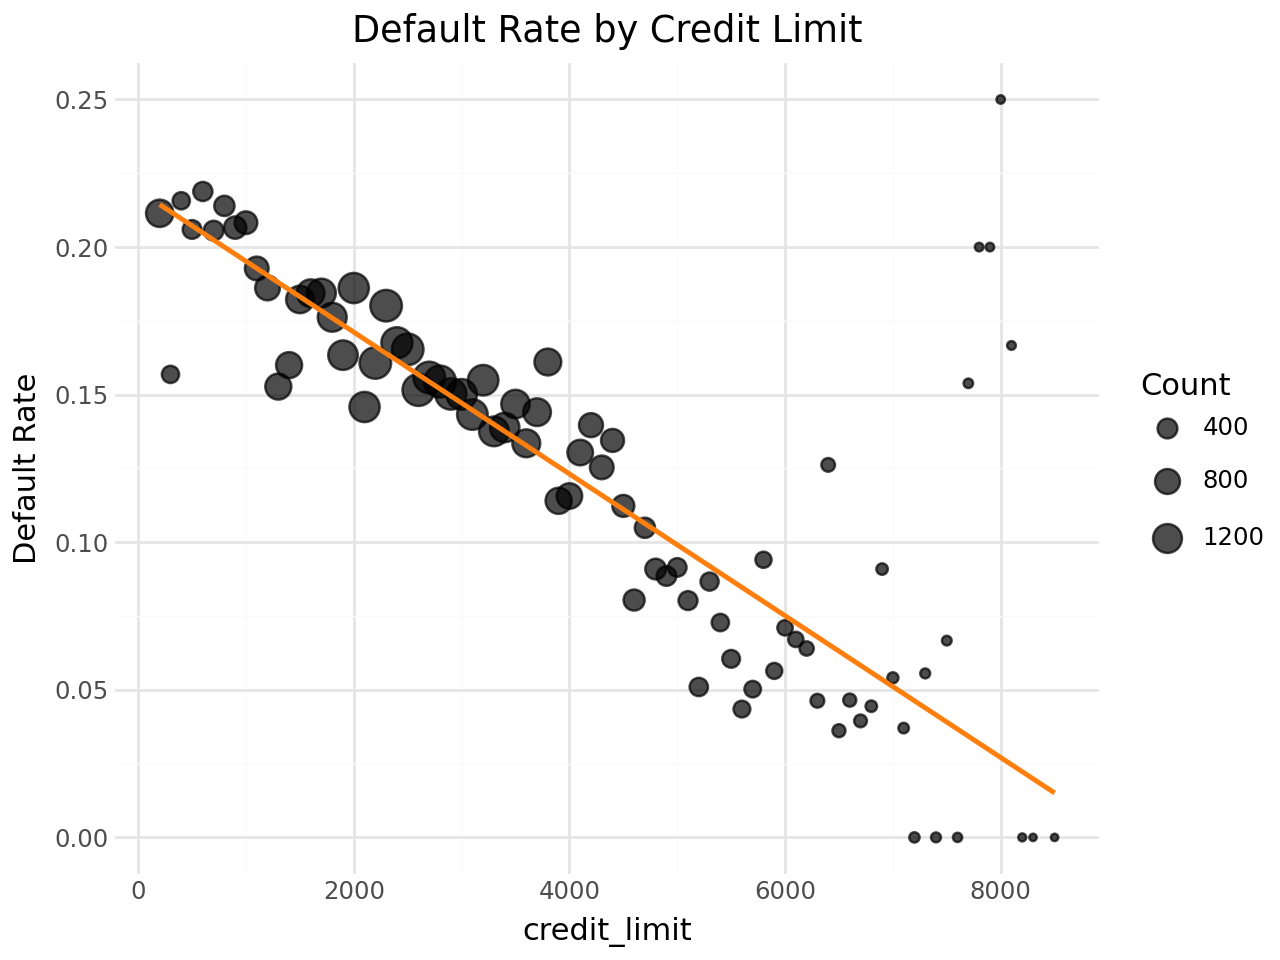

In [76]:
import polars as pl
from plotnine import *

plt_df = (
    risk_data
    .group_by("credit_limit")
    .agg([
        pl.col("default").mean(),       # Calcula el promedio de default
        pl.len().alias("size")          # Cuenta las filas (equivalente a sum size)
    ])
    .sort("credit_limit")               # Ordenamos para que la línea del gráfico salga bien
)

preds = model.predict(plt_df.to_pandas())

# Añadimos la columna de predicción al DataFrame de Polars
plt_df = plt_df.with_columns(
    prediction = pl.Series(preds)
)

(
    ggplot(plt_df, aes(x="credit_limit")) +
    
    # Capa 1: Los puntos (sns.scatterplot)
    # Mapeamos 'size' al tamaño para tener las burbujas
    geom_point(aes(y="default", size="size"), alpha=0.7) +
    
    # Capa 2: La línea de predicción (plt.plot)
    # Usamos la columna 'prediction' que calculaste
    geom_line(aes(y="prediction"), color="#ff7f0e", size=1) + # color C1 es naranja aprox
    
    # Ajustes visuales para que se vea igual
    labs(
        title="Default Rate by Credit Limit",
        y="Default Rate",
        size="Count" # Etiqueta de la leyenda de tamaño
    ) +
    theme_minimal()
)

In [77]:
(
    risk_data.group_by(["credit_score1", "credit_score2"])
             .len()
             .sort("credit_score1")
             .head(10)
)

credit_score1,credit_score2,len
f64,f64,u32
34.0,500.0,1
34.0,339.0,1
52.0,518.0,1
69.0,357.0,1
69.0,393.0,1
69.0,214.0,1
86.0,446.0,1
103.0,250.0,1
103.0,446.0,1


In [78]:
formula = "default ~ credit_limit + wage + credit_score1 + credit_score2"
model = smf.ols(formula, data=risk_data.to_pandas()).fit()
model.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,0.4037,0.009,46.939,0.000,0.387,0.421
credit_limit,3.063e-06,1.54e-06,1.987,0.047,4.16e-08,6.08e-06
wage,-8.822e-05,6.07e-06,-14.541,0.000,-0.000,-7.63e-05
credit_score1,-4.175e-05,1.83e-05,-2.278,0.023,-7.77e-05,-5.82e-06
credit_score2,-0.0003,1.52e-05,-20.055,0.000,-0.000,-0.000


In [79]:
import statsmodels.api as sm
X = risk_data[['wage','credit_score1','credit_score2']].to_pandas()
X = sm.add_constant(X)
res_t = sm.OLS(risk_data['credit_limit'], X).fit()
r_t = res_t.resid
res_y = sm.OLS(risk_data['default'], X).fit()
r_y = res_y.resid
beta1 = sm.OLS(r_y, r_t).fit().params[0]
print('beta1 (FWL):', beta1)

beta1 (FWL): 3.062527732125304e-06


C:\Users\sergi\AppData\Local\Temp\ipykernel_23068\2620109530.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


## Explicación Paso a Paso del Teorema Frisch-Waugh-Lovell (FWL)

El **Teorema FWL** es una herramienta poderosa en regresión lineal que permite separar el efecto de interés (del tratamiento) de los efectos de los confundidores. Básicamente, demuestra que el coeficiente de una variable en una regresión múltiple es igual al coeficiente obtenido al regredir los residuos de ambas variables sobre los residuos de los confundidores.

**Intuición:**  
FWL permite "limpiar" el tratamiento y el outcome de la influencia de los confundidores, y luego estimar el efecto causal usando solo la variación "ortogonal" (independiente) de los confundidores.

**Pasos del algoritmo FWL:**
1. Seleccionar las variables confundidoras (X).
2. Regresar el tratamiento (T) sobre X y obtener los residuos (r_T).
3. Regresar el outcome (Y) sobre X y obtener los residuos (r_Y).
4. Regresar r_Y sobre r_T para obtener β₁ (el efecto causal ajustado).

**Ventajas:**
- Separa el "des-biasing" del análisis final.
- Permite reutilizar el tratamiento residualizado para múltiples outcomes sin recalcular X.
- Es la base de técnicas modernas como Double Machine Learning (DML).

In [80]:
# Paso 1: Seleccionar las variables confundidoras (X) y añadir constante
# X son las variables que queremos mantener fijas al estimar el efecto causal
X = risk_data[['wage', 'credit_score1', 'credit_score2']].to_pandas()
X = sm.add_constant(X)  # Añade la columna de intercepto (constante) para la regresión
print("Matriz X (primeras 5 filas):")
X.head()

Matriz X (primeras 5 filas):


,const,wage,credit_score1,credit_score2
0,1.0,950.0,500.0,518.0
1,1.0,780.0,414.0,429.0
2,1.0,1230.0,586.0,571.0
3,1.0,1040.0,379.0,411.0
4,1.0,1000.0,379.0,518.0


In [81]:
# Paso 2: Regresar el tratamiento (T) sobre X y obtener residuos (r_T)
# Esto captura la parte del tratamiento explicada por los confundidores
res_t = sm.OLS(risk_data['credit_limit'], X).fit()
r_t = res_t.resid  # Residuos: variación en T no explicada por X
print("Residuos de T (r_T) - primeros 5 valores:")
print(r_t.head())
print(f"R² de la regresión T ~ X: {res_t.rsquared:.4f}")  # Qué porcentaje de T explica X

Residuos de T (r_T) - primeros 5 valores:
0     499.013906
1    -517.483433
2     816.564174
3   -1127.636740
4    -763.910173
dtype: float64
R² de la regresión T ~ X: 0.4448


In [82]:
# Paso 3: Regresar el outcome (Y) sobre X y obtener residuos (r_Y)
# Esto captura la parte del outcome explicada por los confundidores
res_y = sm.OLS(risk_data['default'], X).fit()
r_y = res_y.resid  # Residuos: variación en Y no explicada por X
print("Residuos de Y (r_Y) - primeros 5 valores:")
print(r_y.head())
print(f"R² de la regresión Y ~ X: {res_y.rsquared:.4f}")  # Qué porcentaje de Y explica X

Residuos de Y (r_Y) - primeros 5 valores:
0   -0.149819
1   -0.193975
2   -0.107511
3   -0.179227
4   -0.150040
dtype: float64
R² de la regresión Y ~ X: 0.0298


In [83]:
# Paso 4: Regresar los residuos de Y sobre los residuos de T
# Esto da el coeficiente causal β₁, ajustado por X
fwl_model = sm.OLS(r_y, r_t).fit()
beta1_fwl = fwl_model.params[0]
print(f"β₁ estimado por FWL: {beta1_fwl}")
print(f"Error estándar: {fwl_model.bse[0]}")
print(f"p-valor: {fwl_model.pvalues[0]}")
print(f"Intervalo de confianza 95%: {fwl_model.conf_int().iloc[0].values}")

β₁ estimado por FWL: 3.062527732125304e-06
Error estándar: 1.5412183880389336e-06
p-valor: 0.04691872836973873
Intervalo de confianza 95%: [4.17220723e-08 6.08333339e-06]


C:\Users\sergi\AppData\Local\Temp\ipykernel_23068\4271264799.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
C:\Users\sergi\AppData\Local\Temp\ipykernel_23068\4271264799.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
C:\Users\sergi\AppData\Local\Temp\ipykernel_23068\4271264799.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


In [84]:
# Comparación: β₁ de la regresión completa vs FWL
# Regresión completa: Y ~ T + X
full_model = sm.OLS(risk_data['default'], sm.add_constant(risk_data[['credit_limit', 'wage', 'credit_score1', 'credit_score2']].to_pandas())).fit()
beta1_full = full_model.params['credit_limit']
print(f"β₁ de regresión completa: {beta1_full}")
print(f"β₁ de FWL: {beta1_fwl}")
print(f"Diferencia: {abs(beta1_full - beta1_fwl)}")  # Debería ser prácticamente cero

β₁ de regresión completa: 3.0625277321251984e-06
β₁ de FWL: 3.062527732125304e-06
Diferencia: 1.0545560193316039e-19


## ¿Por qué FWL simplifica OLS y es útil en inferencia causal?

**Equivalencia algebraica:**  
FWL demuestra que el coeficiente de `credit_limit` en la regresión completa `default ~ credit_limit + wage + credit_score1 + credit_score2` es **exactamente igual** al coeficiente obtenido al regredir los residuos `r_y ~ r_t`. Esto es una identidad matemática bajo OLS.

**Simplificación conceptual:**  
- **Separa el "des-biasing" del análisis:** Primero "limpias" el tratamiento y el outcome de los confundidores (pasos 1-3), luego estimas el efecto causal (paso 4).
- **Reutilización:** Si tienes múltiples outcomes, solo calculas `r_t` una vez y luego regresas cada `r_y` sobre `r_t`. No necesitas recalcular los efectos de X cada vez.
- **Interpretación clara:** `r_t` es la variación en el tratamiento que no está correlacionada con X. `r_y` es la variación en el outcome que no está correlacionada con X. Al relacionarlos, obtienes el efecto causal "puro".

**Ventajas prácticas en causalidad:**  
- **Preprocesamiento:** Permite "des-biasear" el tratamiento una vez y compartirlo con otros analistas sin que conozcan los confundidores.
- **Base de métodos avanzados:** FWL es fundamental para técnicas como Double Machine Learning (DML), donde usas ML para estimar los residuos en lugar de OLS.
- **Robustez:** Si X está bien especificado, FWL elimina el sesgo por confundidores observados, permitiendo una interpretación causal más confiable.

**Nota importante:** FWL asume linealidad y OLS. Si el modelo es no lineal, la equivalencia no se mantiene exactamente. Además, no elimina sesgo por variables no observadas.

## Regression Theory

In [85]:
x_cols = ['credit_limit', 'wage', 'credit_score1', 'credit_score2']
x = risk_data.select(x_cols).with_columns(
    pl.lit(1).alias('intercept')
)
y = risk_data.select(pl.col('default'))

def regress(y, x):
    x = x.to_numpy()
    y = y.to_numpy()
    return np.linalg.inv(x.T @ x) @ x.T @ y

beta = regress(y, x)
beta

array([[ 3.06252773e-06],
       [-8.82159125e-05],
       [-4.17472814e-05],
       [-3.03928359e-04],
       [ 4.03661277e-01]])

### Notas clave sobre regresión lineal y redes neuronales (1 capa)

- La regresión lineal clásica (OLS) tiene una **solución analítica**: calcula los coeficientes óptimos directamente usando álgebra lineal, sin iteraciones.
- Una red neuronal de una sola capa (sin activación) es **matemáticamente equivalente** a la regresión lineal, pero normalmente se entrena usando **gradiente descendente** (iterativo).
- Ambas buscan minimizar el error cuadrático medio (MSE), pero la forma de encontrar los coeficientes/pesos puede ser directa (analítica) o aproximada (iterativa).
- En problemas pequeños o medianos, la solución analítica es rápida y exacta. En problemas grandes o con modelos más complejos, se prefiere el método iterativo.
- En causalidad, la regresión lineal permite estimar efectos ajustando por confundidores, y su interpretación es clara y directa.

In [86]:
formula = "default ~ credit_limit + wage + credit_score1 + credit_score2"
model = smf.ols(formula, data=risk_data.to_pandas()).fit()
model.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,0.4037,0.009,46.939,0.000,0.387,0.421
credit_limit,3.063e-06,1.54e-06,1.987,0.047,4.16e-08,6.08e-06
wage,-8.822e-05,6.07e-06,-14.541,0.000,-0.000,-7.63e-05
credit_score1,-4.175e-05,1.83e-05,-2.278,0.023,-7.77e-05,-5.82e-06
credit_score2,-0.0003,1.52e-05,-20.055,0.000,-0.000,-0.000


### Debiasing Step

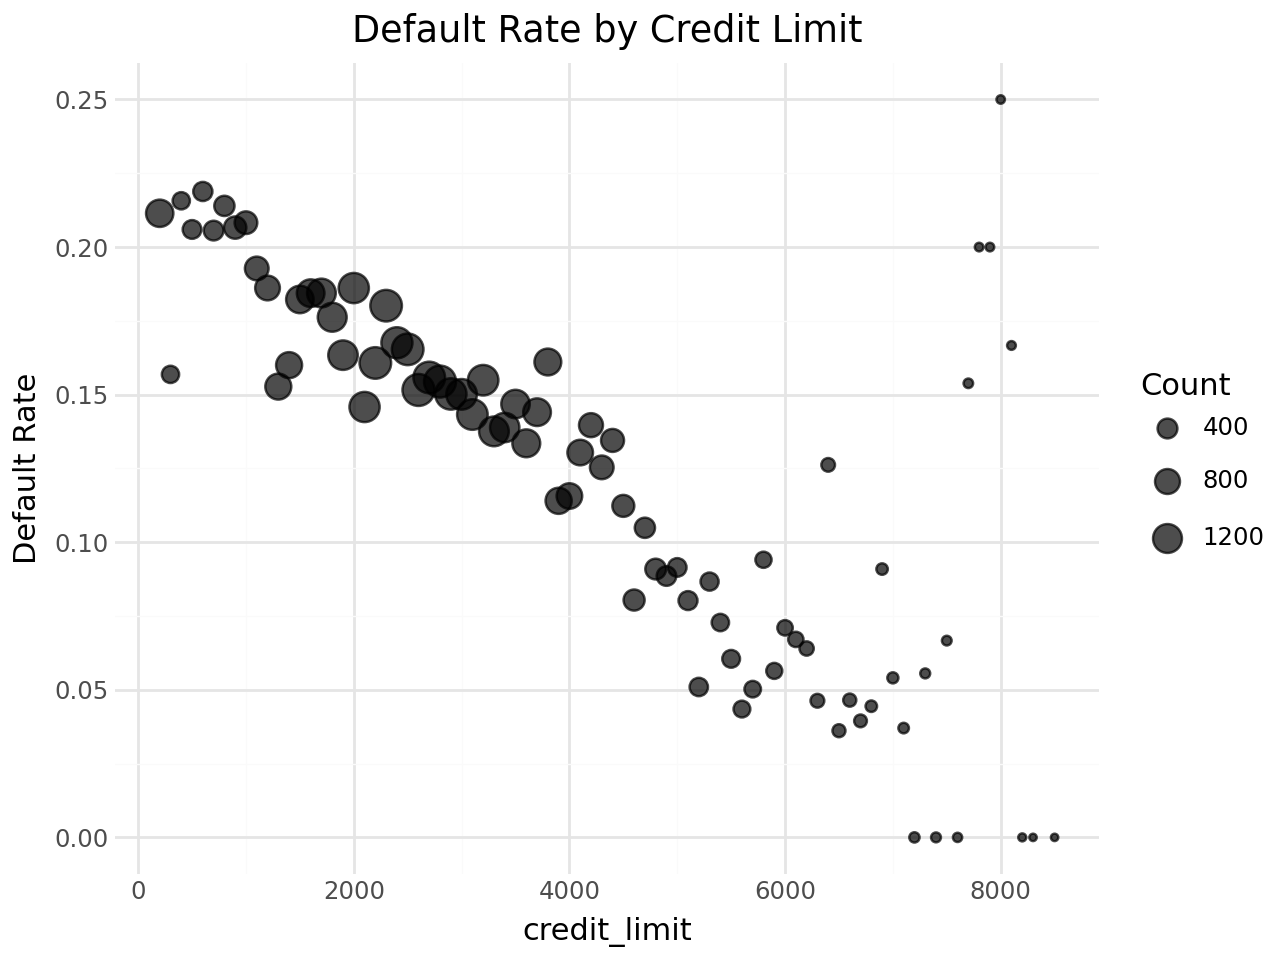

In [87]:
import polars as pl
from plotnine import *

model = smf.ols("default ~ credit_limit", data=risk_data.to_pandas()).fit()
model.summary().tables[1]

plt_df = (
    risk_data
    .group_by("credit_limit")
    .agg([
        pl.col("default").mean(),       # Calcula el promedio de default
        pl.len().alias("size")          # Cuenta las filas (equivalente a sum size)
    ])
    .sort("credit_limit")               # Ordenamos para que la línea del gráfico salga bien
)

preds = model.predict(plt_df.to_pandas())

# Añadimos la columna de predicción al DataFrame de Polars
plt_df = plt_df.with_columns(
    prediction = pl.Series(preds)
)

(
    ggplot(plt_df, aes(x="credit_limit")) +
    
    # Capa 1: Los puntos (sns.scatterplot)
    # Mapeamos 'size' al tamaño para tener las burbujas
    geom_point(aes(y="default", size="size"), alpha=0.7) +
    
    # Ajustes visuales para que se vea igual
    labs(
        title="Default Rate by Credit Limit",
        y="Default Rate",
        size="Count" # Etiqueta de la leyenda de tamaño
    ) +
    theme_minimal()
)

In [88]:

debiasing_model = smf.ols("credit_limit ~ wage + credit_score1 + credit_score2", 
                          data=risk_data.to_pandas()).fit()
residuos = debiasing_model.resid +risk_data.select(pl.col("credit_limit")).mean().item()  # Esto es un array de pandas

# Asegúrate de que la longitud coincida con el DataFrame original
risk_data_deb = risk_data.with_columns(
    pl.Series("credit_limit_res", residuos)
)

risk_data_deb

wage,educ,exper,married,credit_score1,credit_score2,credit_limit,default,credit_limit_res
f64,i64,i64,i64,f64,f64,f64,i64,f64
950.0,11,16,1,500.0,518.0,3200.0,0,3347.583906
780.0,11,7,1,414.0,429.0,1700.0,0,2331.086567
1230.0,14,9,1,586.0,571.0,4200.0,0,3665.134174
1040.0,15,8,1,379.0,411.0,1500.0,0,1720.93326
1000.0,16,1,1,379.0,518.0,1800.0,0,2084.659827
…,…,…,…,…,…,…,…,…
840.0,12,13,1,466.0,482.0,2400.0,0,2817.487623
700.0,15,16,1,328.0,393.0,1100.0,0,2044.247688
930.0,14,16,1,552.0,339.0,1700.0,0,1802.366493


In [89]:
model_w_deb_data = smf.ols("default ~ credit_limit_res",
                            data=risk_data_deb.to_pandas()).fit()
model_w_deb_data.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,0.1421,0.005,30.001,0.000,0.133,0.151
credit_limit_res,3.063e-06,1.56e-06,1.957,0.050,-4.29e-09,6.13e-06


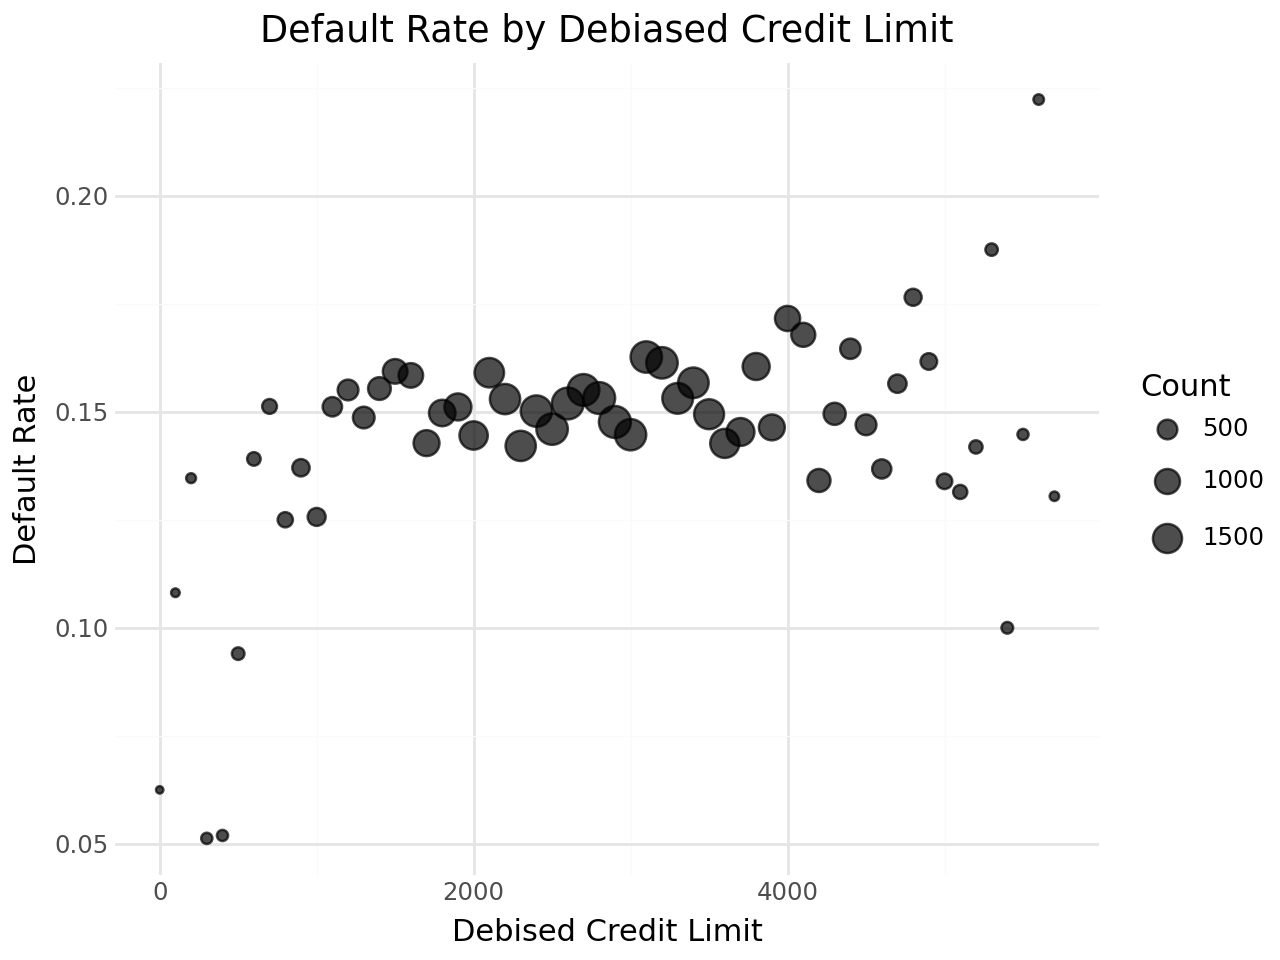

In [90]:
plot_df_deb = (
    risk_data_deb
    .with_columns(
        (pl.col("credit_limit_res") / 100).round().mul(100).alias("credit_limit_res")
    )
    .group_by("credit_limit_res")
    .agg([
        pl.col("default").mean(),
        pl.len().alias("size")
    ])
    .filter(pl.col("size") > 30)
)

(
    ggplot(plot_df_deb, aes(x="credit_limit_res")) +
    
    # Capa 1: Los puntos (sns.scatterplot)
    # Mapeamos 'size' al tamaño para tener las burbujas
    geom_point(aes(y="default", size="size"), alpha=0.7) +
    
    # Ajustes visuales para que se vea igual
    labs(
        x="Debised Credit Limit",
        title="Default Rate by Debiased Credit Limit",
        y="Default Rate",
        size="Count" # Etiqueta de la leyenda de tamaño
    ) +
    theme_minimal()
)

### Denoising Step

In [91]:
denoising_model = smf.ols(
    'default ~ wage + credit_score1 + credit_score2',
    data=risk_data_deb.to_pandas()
).fit()

default_res = denoising_model.resid + risk_data_deb.select(pl.col("default")).mean().item()

risk_data_denoise = risk_data_deb.with_columns(
    default_res=pl.Series(default_res),
)
risk_data_denoise

wage,educ,exper,married,credit_score1,credit_score2,credit_limit,default,credit_limit_res,default_res
f64,i64,i64,i64,f64,f64,f64,i64,f64,f64
950.0,11,16,1,500.0,518.0,3200.0,0,3347.583906,0.000981
780.0,11,7,1,414.0,429.0,1700.0,0,2331.086567,-0.043175
1230.0,14,9,1,586.0,571.0,4200.0,0,3665.134174,0.043289
1040.0,15,8,1,379.0,411.0,1500.0,0,1720.93326,-0.028427
1000.0,16,1,1,379.0,518.0,1800.0,0,2084.659827,0.00076
…,…,…,…,…,…,…,…,…,…
840.0,12,13,1,466.0,482.0,2400.0,0,2817.487623,-0.020257
700.0,15,16,1,328.0,393.0,1100.0,0,2044.247688,-0.063805
930.0,14,16,1,552.0,339.0,1700.0,0,1802.366493,-0.053155


### Error Estándar del Estimador de Regresión

El **error estándar del coeficiente de regresión** ($\beta$) mide la variabilidad de nuestro estimador $\hat{\beta}$ alrededor del verdadero valor poblacional $\beta$. En otras palabras, nos indica cuánto podemos confiar en que $\hat{\beta}$ sea cercano al efecto causal real.

**Fórmula básica (para un coeficiente simple):**
$$
SE_{\hat{\beta}} = \frac{\sigma_e}{\sigma_T \sqrt{n - DF}}
$$
Donde:
- $\sigma_e$: Es el error estándar residual (la desviación estándar de los residuos del modelo).
- $\sigma_T$: La desviación estándar de la variable de tratamiento ($T$, en este caso `credit_limit`).
- $n$: El tamaño de la muestra.
- $DF$: Los grados de libertad del modelo (número de parámetros estimados, por ejemplo, 5 en una regresión con intercepto y 4 variables).

**Intuición:**  
Imagina que $\sigma_e$ es el "ruido" que queda después de ajustar por los confundidores. Si el tratamiento $T$ varía mucho (alta $\sigma_T$), y tenemos muchos datos ($n$ grande), el error estándar será pequeño, lo que significa mayor precisión en el estimador. En causalidad, un $SE$ bajo nos da confianza en que el efecto estimado no es solo ruido.

**Interpretación en inferencia causal:**  
- Si el intervalo de confianza $95\%$ de $\hat{\beta}$ no incluye cero, podemos decir que hay un efecto causal significativo.
- En regresión múltiple (como en nuestros ejemplos), el $SE$ se calcula usando la matriz de varianza-covarianza de OLS, pero la idea es la misma: cuantifica la incertidumbre.




In [92]:
model_se  = smf.ols(
    "default ~ wage + credit_score1 + credit_score2",
    data=risk_data.to_pandas()
).fit()
print("SE regression:", model_se.bse["wage"])

model_wage_aux = smf.ols(
    "wage ~ credit_score1 + credit_score2",
    data=risk_data.to_pandas()
).fit()

# Substract the degrees of freedom -4 model parameters - from N.
se_formula =(np.std(model_se.resid)) / (np.std(model_wage_aux.resid)*np.sqrt(len(risk_data) - 4))
print("SE via formula:", se_formula)

SE regression: 5.36424234754825e-06
SE via formula: 5.36424234754819e-06


### Final Outcome Model

In [93]:
model_w_orthogonal = smf.ols(
    "default_res ~ credit_limit_res",
    data=risk_data_denoise.to_pandas()
).fit()
model_w_orthogonal.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,0.1421,0.005,30.458,0.000,0.133,0.151
credit_limit_res,3.063e-06,1.54e-06,1.987,0.047,4.17e-08,6.08e-06


In [94]:
risk_data_denoise

wage,educ,exper,married,credit_score1,credit_score2,credit_limit,default,credit_limit_res,default_res
f64,i64,i64,i64,f64,f64,f64,i64,f64,f64
950.0,11,16,1,500.0,518.0,3200.0,0,3347.583906,0.000981
780.0,11,7,1,414.0,429.0,1700.0,0,2331.086567,-0.043175
1230.0,14,9,1,586.0,571.0,4200.0,0,3665.134174,0.043289
1040.0,15,8,1,379.0,411.0,1500.0,0,1720.93326,-0.028427
1000.0,16,1,1,379.0,518.0,1800.0,0,2084.659827,0.00076
…,…,…,…,…,…,…,…,…,…
840.0,12,13,1,466.0,482.0,2400.0,0,2817.487623,-0.020257
700.0,15,16,1,328.0,393.0,1100.0,0,2044.247688,-0.063805
930.0,14,16,1,552.0,339.0,1700.0,0,1802.366493,-0.053155


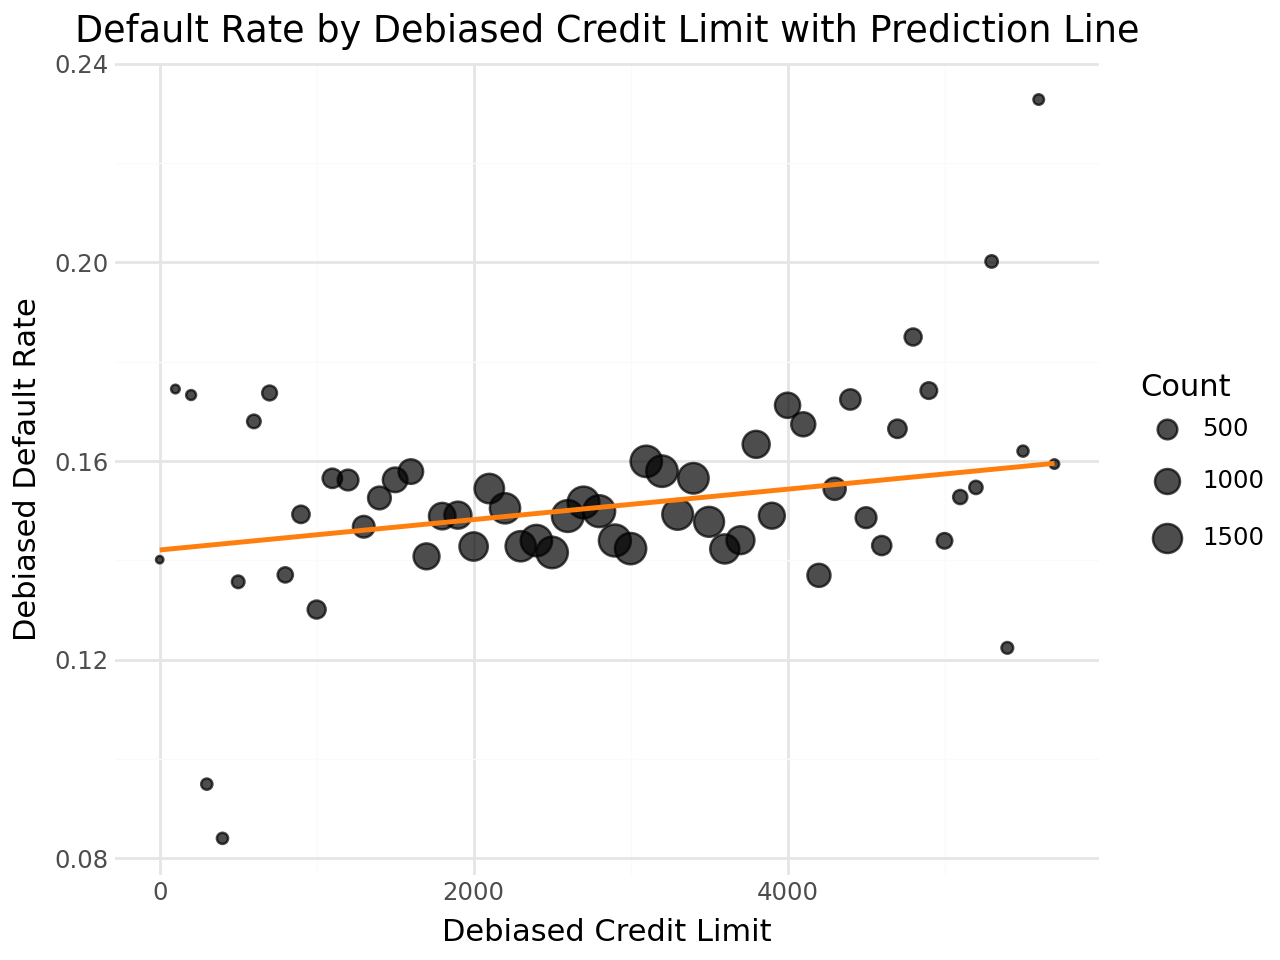

In [95]:
# Construimos el DataFrame agrupado y añadimos las predicciones del modelo ortogonalizado
plt_df_orth = (
    risk_data_denoise.with_columns(
        credit_limit_res=((pl.col("credit_limit_res") / pl.lit(100)).round().mul(100))
    )
    .group_by(pl.col("credit_limit_res"))
    .agg(pl.col("default_res").mean(),
         pl.len().alias("size"))
    .filter(pl.col("size") > 30)
    .sort(by=pl.col("credit_limit_res"))
)

plt_df_orth = plt_df_orth.with_columns(
    preds=pl.Series(model_w_orthogonal.predict(
        plt_df_orth.select(
            pl.col("credit_limit_res"))
.to_pandas()
        )
    )
)


g = (
    ggplot(data=plt_df_orth, mapping=aes(x="credit_limit_res"))
    + geom_point(aes(y="default_res", size="size"), alpha=0.7)
    + geom_line(aes(y="preds"), color="#ff7f0e", size=1)
    + labs(
        x="Debiased Credit Limit",
        title="Default Rate by Debiased Credit Limit with Prediction Line",
        y="Debiased Default Rate",
        size="Count"
    )
    + theme_minimal()
    )
g

#### Resumen Visual y Matemático: Teorema Frisch-Waugh-Lovell (FWL)

El teorema FWL nos permite entender la regresión múltiple como un proceso de **ortogonalización** en tres pasos. Es una técnica fundamental para aislar el efecto causal de un tratamiento $T$ sobre un resultado $Y$, eliminando la influencia de los confundidores $X$.

### 1. El Problema: Confusión
Queremos estimar el efecto causal de $T$ en $Y$, pero $X$ afecta a ambos.
$$ Y = \beta_1 T + \beta_2 X + e $$
Si ignoramos $X$, nuestra estimación de $\beta_1$ estará sesgada.

### Paso 1: Debiasing del Tratamiento (Limpiar la Causa)
Aislamos la variación de $T$ que **no** depende de $X$.
1.  Regresamos $T$ sobre $X$: $\hat{T} = \hat{\alpha}_0 + \hat{\alpha}_1 X$.
2.  Calculamos los residuos:
    $$ \tilde{T} = T - \hat{T} $$
    *Intuición:* $\tilde{T}$ es el tratamiento "purificado" de la influencia de los confundidores.

### Paso 2: Denoising del Resultado (Limpiar el Efecto)
Aislamos la variación de $Y$ que **no** depende de $X$.
1.  Regresamos $Y$ sobre $X$: $\hat{Y} = \hat{\gamma}_0 + \hat{\gamma}_1 X$.
2.  Calculamos los residuos:
    $$ \tilde{Y} = Y - \hat{Y} $$
    *Intuición:* $\tilde{Y}$ es el resultado "purificado", eliminando el ruido explicado por $X$.

### Paso 3: Estimación Causal
Finalmente, relacionamos las partes "puras" de $T$ y $Y$.
1.  Regresamos $\tilde{Y}$ sobre $\tilde{T}$:
    $$ \tilde{Y} = \beta_1 \tilde{T} + \epsilon $$
2.  **Resultado Clave:** El coeficiente $\beta_1$ obtenido aquí es **idéntico** al de la regresión múltiple original.

### Nota sobre el Intercepto
Al trabajar con residuos (que tienen media cero), la regresión final pasa por el origen.
$$ \text{Intercepto} \approx 0 $$
Esto es esperado: nos interesa la **pendiente** (el efecto causal marginal), no el nivel base.

### ATT vs. ATE: Definición, Fórmulas y Cálculo Práctico

#### **1. ATT (Average Treatment effect on the Treated)**

El **ATT** mide el efecto causal promedio del tratamiento, pero **solo en los individuos que realmente recibieron el tratamiento** ($T=1$):

$$
ATT = E[Y(1) - Y(0) \mid T=1]
$$

**Cálculo práctico (imputación):**
1. Ajusta un modelo para predecir $Y$ en los controles ($T=0$): $\hat{\mu}_0(X)$.
2. Para cada tratado, calcula la diferencia entre su $Y$ observado y el $Y$ contrafactual imputado:

$$
\widehat{ATT} = \frac{1}{N_1} \sum_{i: T_i=1} \left[ Y_i - \hat{\mu}_0(X_i) \right]
$$

donde $N_1$ es el número de tratados.

---

#### **2. ATE (Average Treatment Effect)**

El **ATE** mide el efecto causal promedio en **toda la población**:

$$
ATE = E[Y(1) - Y(0)]
$$

**Cálculo práctico (imputando ambos potenciales):**
1. Ajusta un modelo para $Y$ en tratados ($T=1$): $\hat{\mu}_1(X)$.
2. Ajusta un modelo para $Y$ en controles ($T=0$): $\hat{\mu}_0(X)$.
3. Para todos los individuos, calcula:

$$
\widehat{ATE} = \frac{1}{N} \sum_{i=1}^N \left[ \hat{\mu}_1(X_i) - \hat{\mu}_0(X_i) \right]
$$

**O bien, imputando solo el potencial faltante:**

$$
\widehat{ATE} = \frac{1}{N} \sum_{i=1}^N \left[ T_i (Y_i - \hat{\mu}_0(X_i)) + (1-T_i)(\hat{\mu}_1(X_i) - Y_i) \right]
$$

---

#### **3. Resumen en código (Python)**

```python
# ATT
ATT = np.mean(df[df.T==1]['Y'] - mu0[df.T==1])

# ATE (ambos potenciales)
ATE = np.mean(mu1 - mu0)

# ATE (solo potencial faltante)
ATE_alt = np.mean(df.T * (df.Y - mu0) + (1 - df.T) * (mu1 - df.Y))
```

---

**Resumen visual:**
- **ATT:** Efecto causal promedio en los tratados.
- **ATE:** Efecto causal promedio en toda la población (tratados y controles).

Ambos se pueden estimar imputando los potenciales no observados usando modelos ajustados en los grupos correspondientes.

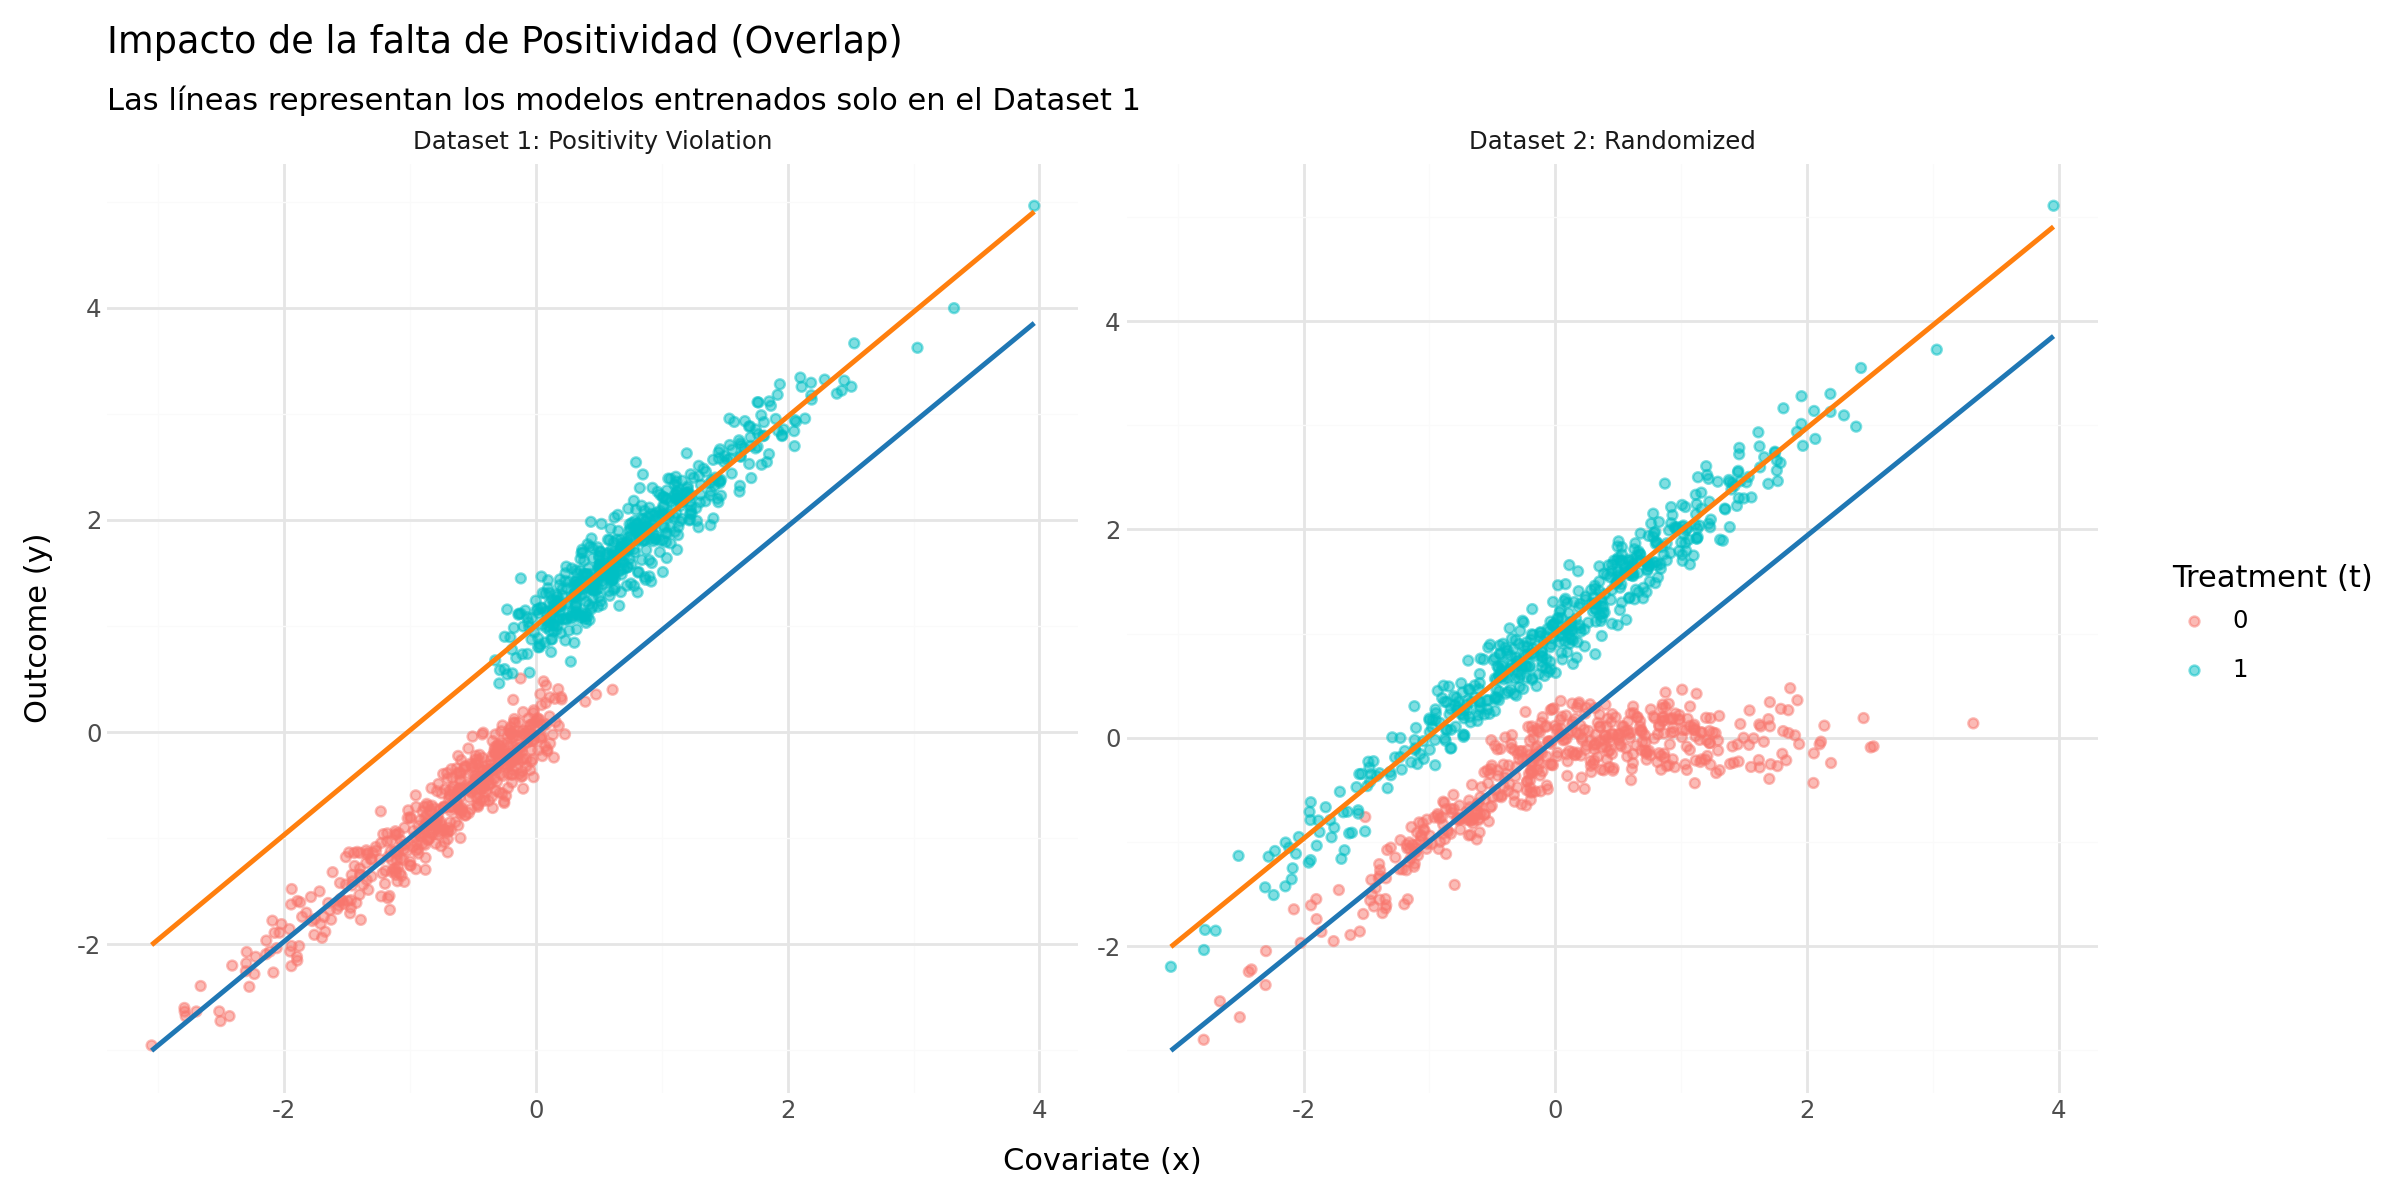

In [96]:
import polars as pl
import numpy as np
import statsmodels.formula.api as smf
from plotnine import *

# 1. Configuración y Generación de Datos
np.random.seed(1)
n = 1000

# --- Dataset 1: Violación de Positividad ---
x_np = np.random.normal(0, 1, n)
t_np = (np.random.normal(x_np, 0.2, n) > 0).astype(int)

y0_np = x_np
y1_np = 1 + x_np
y_np = np.random.normal((1 - t_np) * y0_np + t_np * y1_np, 0.2)

df_no_pos = pl.DataFrame({
    "x": x_np,
    "t": t_np,
    "y": y_np,
    "dataset": "Dataset 1: Positivity Violation"
}).with_columns(pl.col("t").cast(pl.Int64)) 

# --- Dataset 2: Asignación Aleatoria ---
np.random.seed(1) 
x_p = np.random.normal(0, 1, n)
t_p = np.random.binomial(1, 0.5, size=n)

y0_p = x_p * (x_p < 0) + (x_p > 0) * 0
y1_p = 1 + x_p
y_p = np.random.normal((1 - t_p) * y0_p + t_p * y1_p, 0.2)

df_pos = pl.DataFrame({
    "x": x_p,
    "t": t_p,
    "y": y_p,
    "dataset": "Dataset 2: Randomized"
}).with_columns(pl.col("t").cast(pl.Int64)) # <--- FIX: Forzamos a Int64

# 2. Modelado (Entrenamos SOLO en df_no_pos)
train_data = df_no_pos.to_pandas()
m0 = smf.ols("y ~ x", data=train_data.query("t == 0")).fit()
m1 = smf.ols("y ~ x", data=train_data.query("t == 1")).fit()

# 3. Preparación para Plotnine
# Ahora concat funcionará porque ambos 't' son Int64
df_combined = pl.concat([df_no_pos, df_pos])

full_data_pd = df_combined.to_pandas()

df_plot = df_combined.with_columns([
    pl.Series(m0.predict(full_data_pd)).alias("pred_t0"),
    pl.Series(m1.predict(full_data_pd)).alias("pred_t1")
])

# Casting a string para que Plotnine lo use como color categórico
df_plot = df_plot.with_columns(pl.col("t").cast(pl.Utf8))

# 4. Visualización
plot = (
    ggplot(df_plot, aes(x="x"))
    + geom_point(aes(y="y", color="t"), alpha=0.5, size=1.5)
    + geom_line(aes(y="pred_t0"), color="#1f77b4", size=1, linetype="solid") 
    + geom_line(aes(y="pred_t1"), color="#ff7f0e", size=1, linetype="solid")
    + facet_wrap("~dataset", scales="free_y")
    + labs(
        title="Impacto de la falta de Positividad (Overlap)",
        subtitle="Las líneas representan los modelos entrenados solo en el Dataset 1",
        y="Outcome (y)",
        x="Covariate (x)",
        color="Treatment (t)"
    )
    + theme_minimal()
    + theme(figure_size=(12, 6))
)

plot

## Nonlinearities in Linear Regression

In [97]:
data = pl.read_csv("../data/spend_data.csv")
data

wage,educ,exper,married,credit_score1,credit_score2,credit_limit,spend
f64,i64,i64,i64,f64,f64,f64,i64
950.0,11,16,1,500.0,518.0,3200.0,3848
780.0,11,7,1,414.0,429.0,1700.0,3144
1230.0,14,9,1,586.0,571.0,4200.0,4486
1040.0,15,8,1,379.0,411.0,1500.0,3327
1000.0,16,1,1,379.0,518.0,1800.0,3508
…,…,…,…,…,…,…,…
840.0,12,13,1,466.0,482.0,2400.0,3441
700.0,15,16,1,328.0,393.0,1100.0,2626
930.0,14,16,1,552.0,339.0,1700.0,3066


In [98]:
data.describe()

statistic,wage,educ,exper,married,credit_score1,credit_score2,credit_limit,spend
str,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",1061.518,13.48886,11.55078,0.89612,471.10254,487.86192,2848.57,3755.35756
"""std""",412.304605,2.20769,4.36497,0.305108,113.401589,117.063919,1372.623633,945.314742
"""min""",120.0,9.0,1.0,0.0,34.0,36.0,200.0,840.0
"""25%""",770.0,12.0,8.0,1.0,397.0,411.0,1900.0,3166.0
"""50%""",1010.0,12.0,11.0,1.0,466.0,482.0,2700.0,3738.0
"""75%""",1270.0,16.0,15.0,1.0,534.0,571.0,3700.0,4298.0
"""max""",3310.0,18.0,23.0,1.0,1034.0,1036.0,8500.0,7539.0


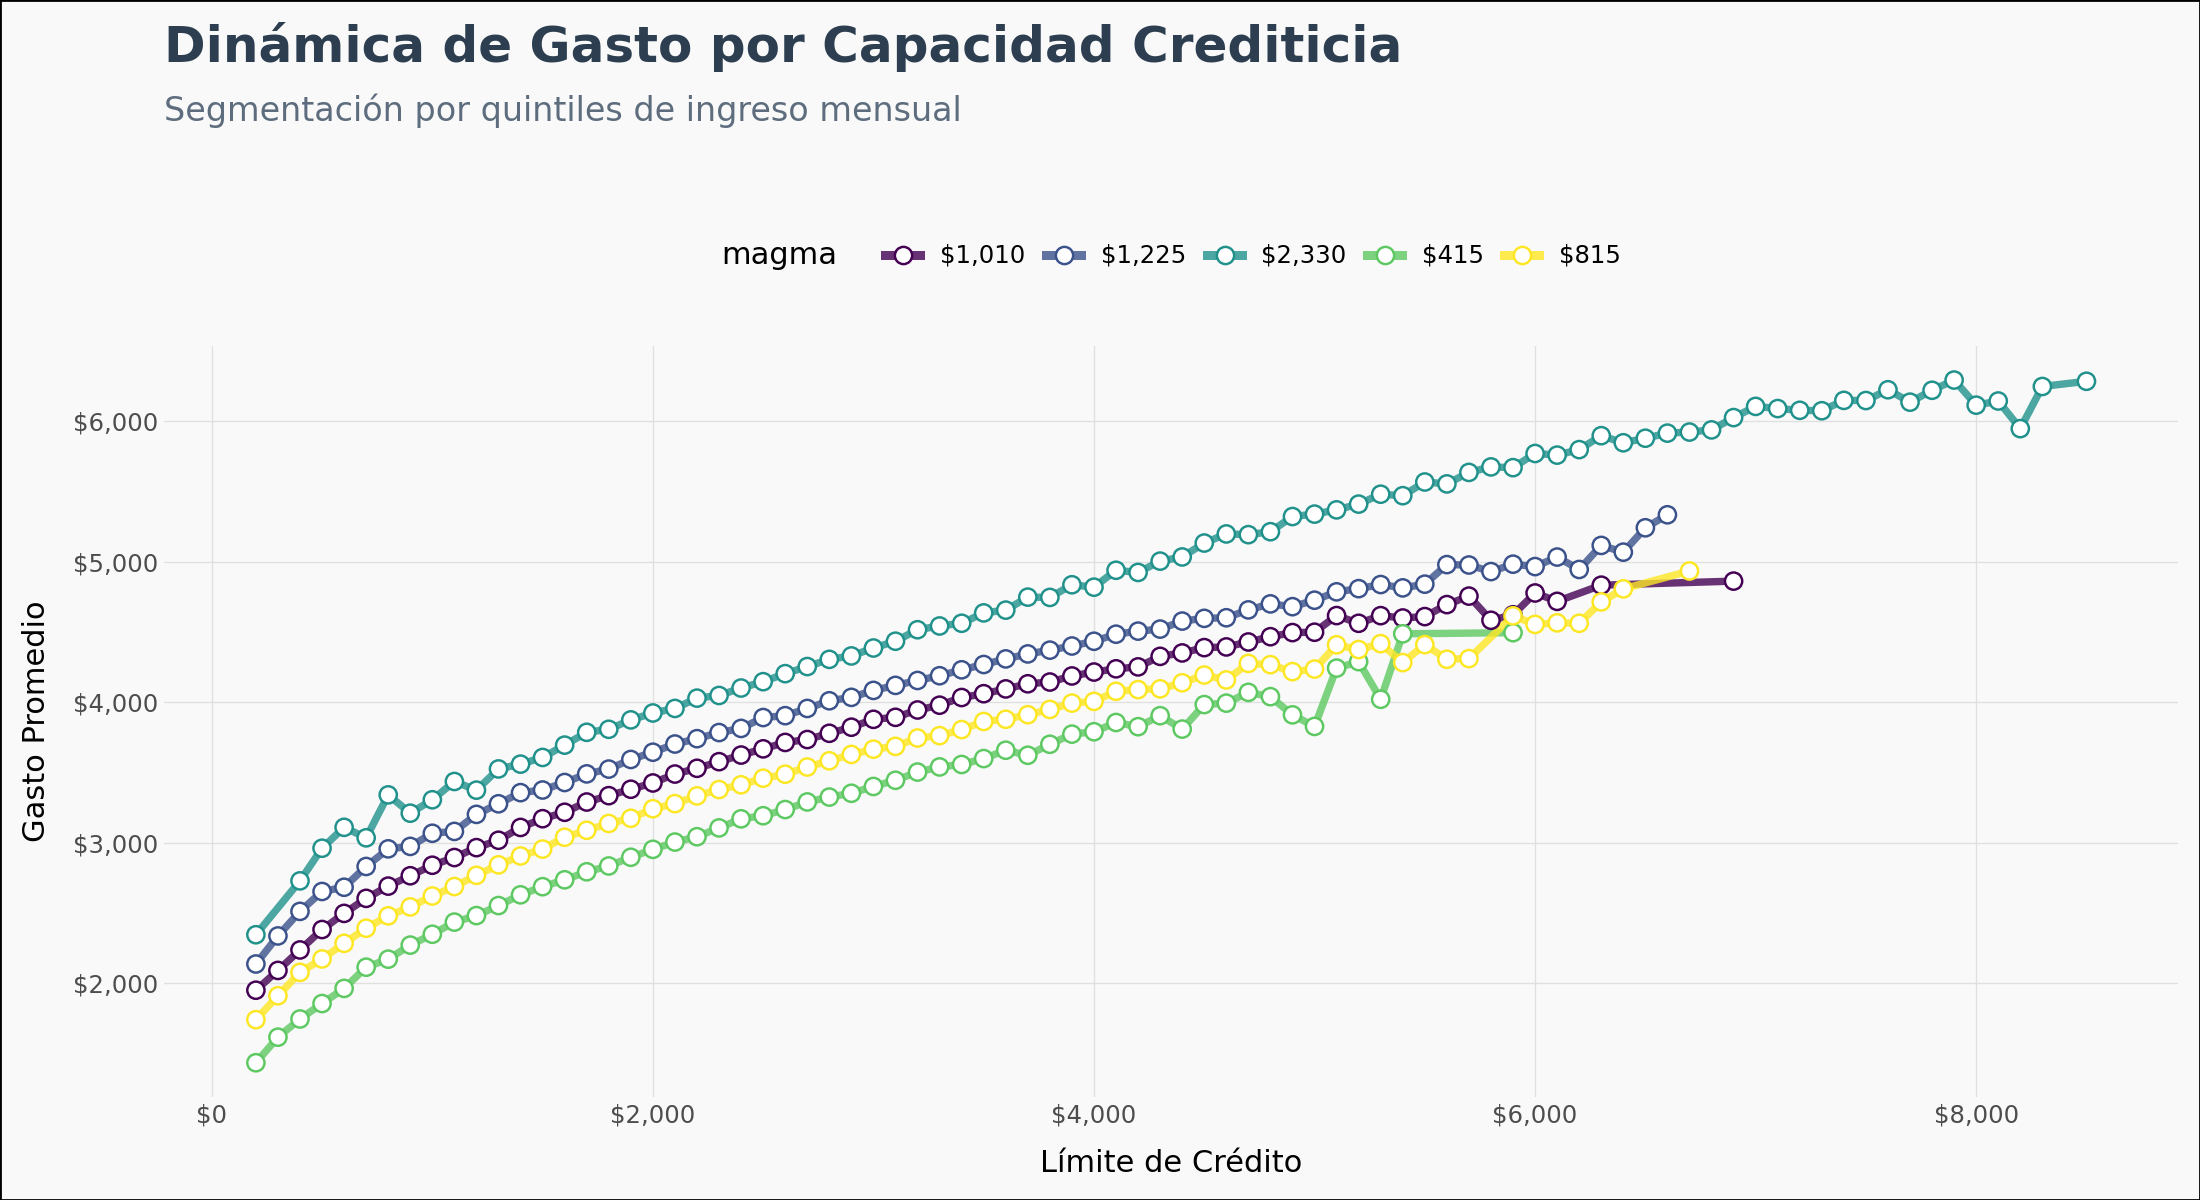

In [99]:
import polars as pl
from plotnine import *

# 1. Procesamiento en Polars
cortes = [data["wage"].quantile(i/5) for i in range(6)]
mids = [(cortes[i] + cortes[i+1]) / 2 for i in range(5)]
labels_money = [f"${int(m):,}" for m in mids]

plt_df = (
    data
    .with_columns(
        wage_group = pl.col("wage")
            .cut(breaks=cortes[1:-1], labels=labels_money)
            .cast(pl.String)
    )
    .group_by(["wage_group", "credit_limit"])
    .agg(pl.col("spend").mean())
    .sort("credit_limit")
)

# 2. Gráfico con escala CMAP (Casi imposible que falle)
p = (
    ggplot(plt_df, aes(x="credit_limit", y="spend", 
                       color="wage_group", group="wage_group")) 
    + geom_line(size=1.5, alpha=0.8) 
    + geom_point(size=3, stroke=0.5, fill="white") 
    # scale_color_cmap_d usa los nombres de matplotlib directamente
    + scale_color_cmap_d(name="magma") 
    + scale_y_continuous(labels=lambda l: [f"${int(x):,}" for x in l])
    + scale_x_continuous(labels=lambda l: [f"${int(x):,}" for x in l])
    + theme_minimal()
    + labs(
        title="Dinámica de Gasto por Capacidad Crediticia",
        subtitle="Segmentación por quintiles de ingreso mensual",
        x="Límite de Crédito",
        y="Gasto Promedio",
        color="Ingreso (Mid)"
    )
    + theme(
        figure_size=(11, 6),
        plot_background=element_rect(fill="#F9F9F9"),
        panel_grid_major=element_line(color="#E0E0E0", size=0.5),
        panel_grid_minor=element_blank(),
        plot_title=element_text(size=18, weight="bold", color="#2C3E50"),
        plot_subtitle=element_text(size=12, color="#5D6D7E", margin={'b': 20}),
        legend_position="top"
    )
)

p

## Linearizing the Treatment

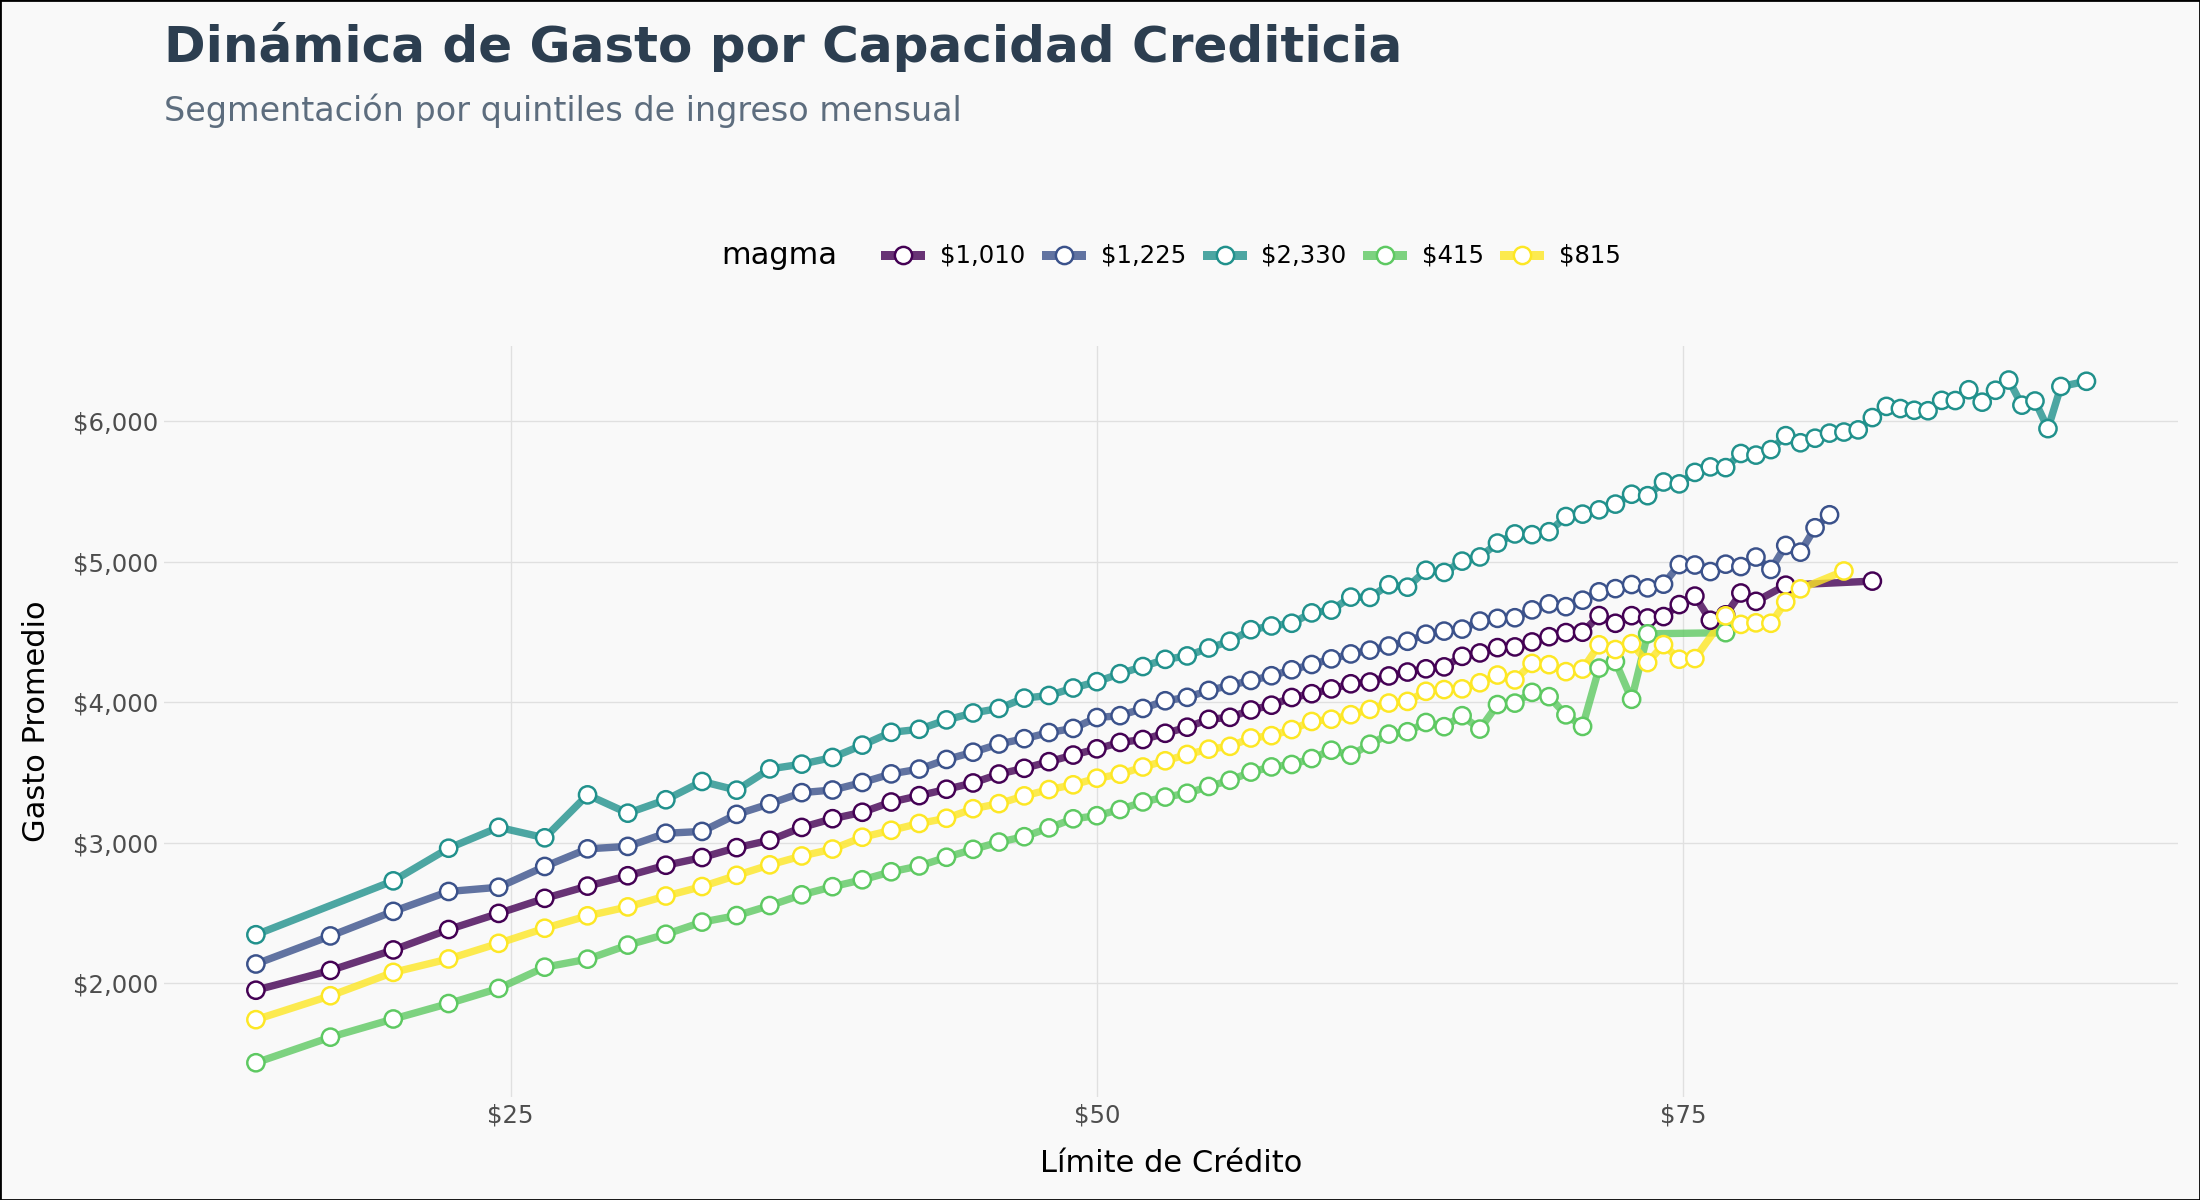

In [100]:
plt_df = plt_df.with_columns(
    credit_limit_sqrt=pl.col("credit_limit").sqrt()
)

p = (
    ggplot(plt_df, aes(x="credit_limit_sqrt", y="spend", 
                       color="wage_group", group="wage_group")) 
    + geom_line(size=1.5, alpha=0.8) 
    + geom_point(size=3, stroke=0.5, fill="white") 
    # scale_color_cmap_d usa los nombres de matplotlib directamente
    + scale_color_cmap_d(name="magma") 
    + scale_y_continuous(labels=lambda l: [f"${int(x):,}" for x in l])
    + scale_x_continuous(labels=lambda l: [f"${int(x):,}" for x in l])
    + theme_minimal()
    + labs(
        title="Dinámica de Gasto por Capacidad Crediticia",
        subtitle="Segmentación por quintiles de ingreso mensual",
        x="Límite de Crédito",
        y="Gasto Promedio",
        color="Ingreso (Mid)"
    )
    + theme(
        figure_size=(11, 6),
        plot_background=element_rect(fill="#F9F9F9"),
        panel_grid_major=element_line(color="#E0E0E0", size=0.5),
        panel_grid_minor=element_blank(),
        plot_title=element_text(size=18, weight="bold", color="#2C3E50"),
        plot_subtitle=element_text(size=12, color="#5D6D7E", margin={'b': 20}),
        legend_position="top"
    )
)

p

In [101]:
model = smf.ols(
    "spend ~ np.sqrt(credit_limit)", data=data.to_pandas()
).fit()

model.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,493.0044,6.501,75.832,0.000,480.262,505.747
np.sqrt(credit_limit),63.2525,0.122,519.268,0.000,63.014,63.491


C:\Users\sergi\AppData\Local\Temp\ipykernel_23068\2059146497.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


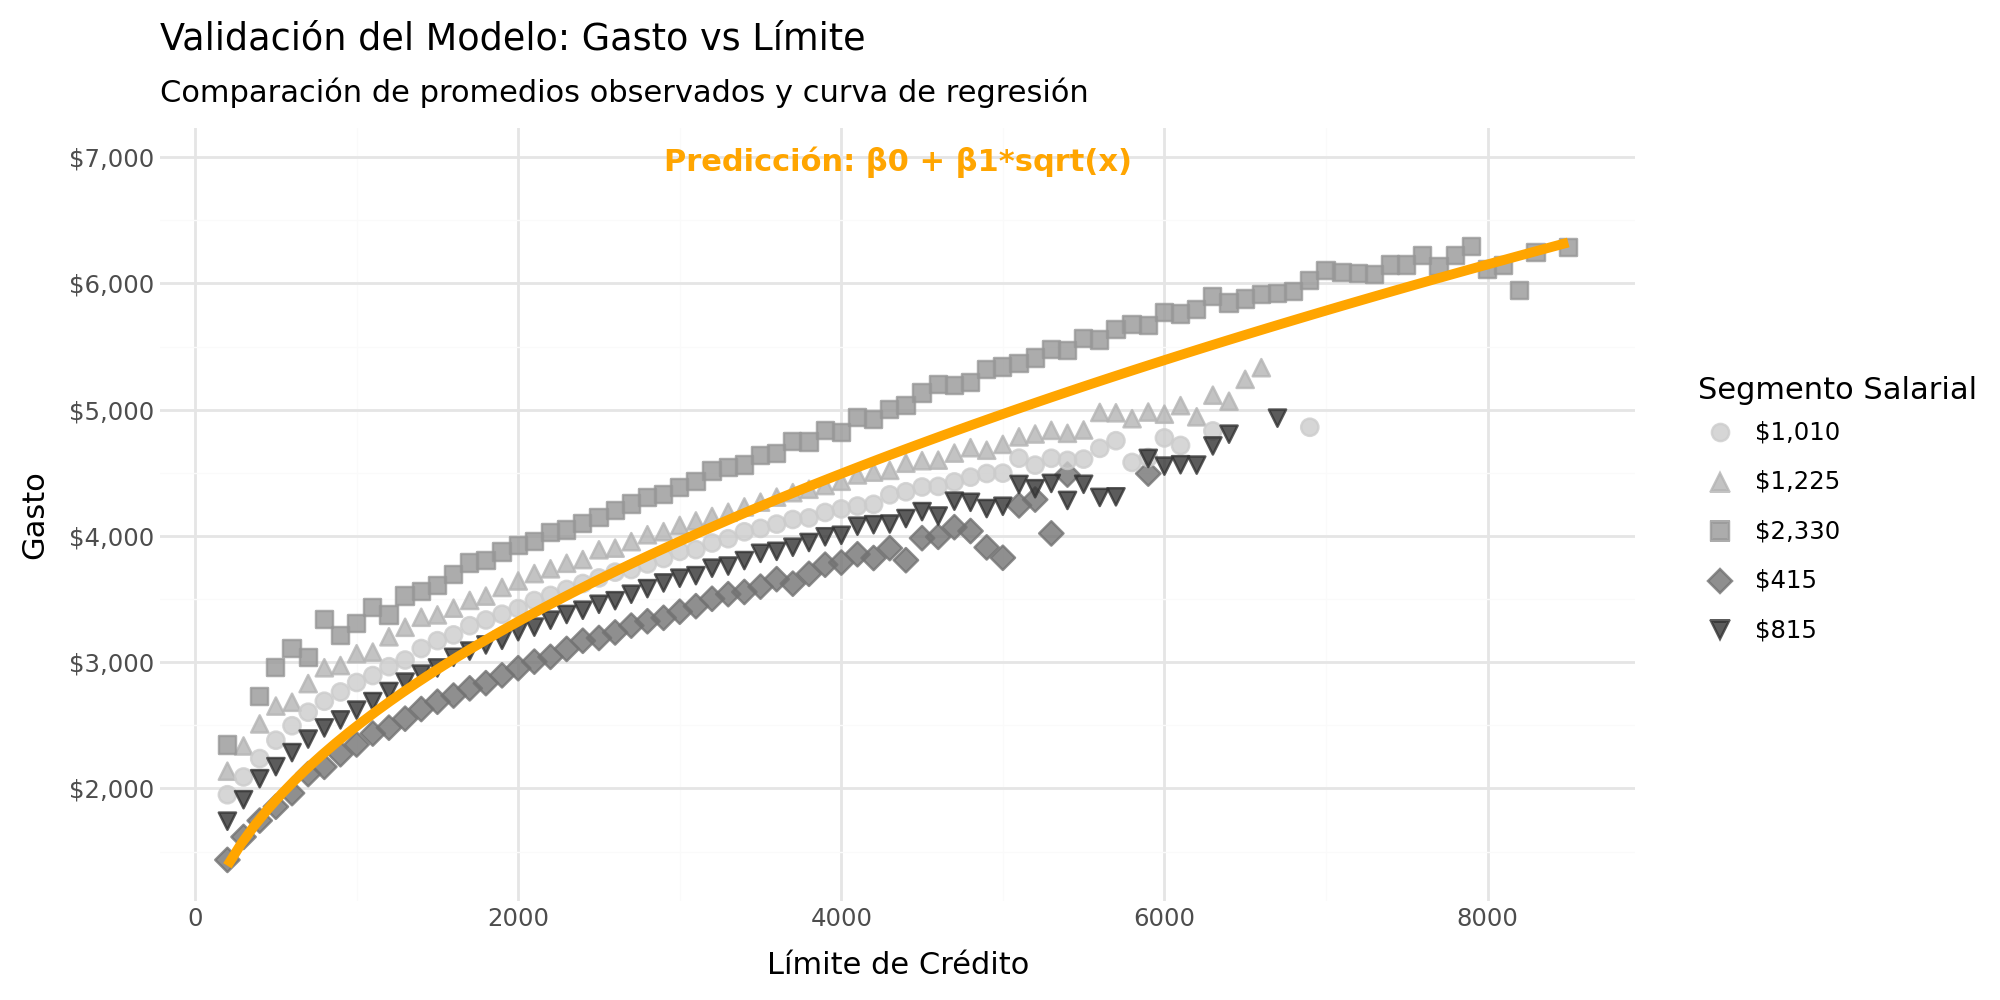

In [102]:
import polars as pl
import numpy as np
from plotnine import *

# 1. Procesamiento de datos con Polars
cortes = [data["wage"].quantile(i/5) for i in range(6)]
mids = [(cortes[i] + cortes[i+1]) / 2 for i in range(5)]
labels_money = [f"${int(m):,}" for m in mids]

plt_df = (
    data
    .with_columns(
        wage_group = pl.col("wage")
            .cut(breaks=cortes[1:-1], labels=labels_money)
            .cast(pl.String)
    )
    .group_by(["wage_group", "credit_limit"])
    .agg(pl.col("spend").mean())
)

# 2. DataFrame para la línea de predicción
x_vals = np.linspace(data["credit_limit"].min(), data["credit_limit"].max(), 100)
y_vals = model.params[0] + model.params[1] * np.sqrt(x_vals)

df_pred = pl.DataFrame({
    "credit_limit": x_vals,
    "spend": y_vals
})

# 3. Gráfico corregido
p = (
    ggplot(plt_df, aes(x="credit_limit", y="spend")) 
    + geom_point(aes(color="wage_group", shape="wage_group"), size=3, alpha=0.8)
    + geom_line(data=df_pred, color="orange", size=2)
    # Corrección: fontweight en lugar de weight, y extracción de escalar (.item())
    + annotate("text", 
               x=df_pred["credit_limit"].median(), 
               y=df_pred["spend"].max() * 1.1, 
               label="Predicción: β0 + β1*sqrt(x)", 
               color="orange", 
               fontweight="bold") # <-- CAMBIO AQUÍ
    + scale_color_grey(start=0.8, end=0.2) 
    + scale_y_continuous(labels=lambda l: [f"${int(x):,}" for x in l])
    + theme_minimal()
    + labs(
        title="Validación del Modelo: Gasto vs Límite",
        subtitle="Comparación de promedios observados y curva de regresión",
        x="Límite de Crédito",
        y="Gasto",
        color="Segmento Salarial",
        shape="Segmento Salarial"
    )
    + theme(figure_size=(10, 5), legend_position="right")
)

p

In [103]:
model_spend = smf.ols("spend ~ np.sqrt(credit_limit) + wage", data=data.to_pandas()).fit()
model_spend.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,383.5002,2.746,139.662,0.000,378.118,388.882
np.sqrt(credit_limit),43.8504,0.065,672.633,0.000,43.723,43.978
wage,1.0459,0.002,481.875,0.000,1.042,1.050


## Nonlinear FWL and Debiasing

### Resumen: FWL No Lineal y Ortogonalización Paso a Paso

Vamos a generalizar el procedimiento de Frisch-Waugh-Lovell (FWL) para el caso donde la relación entre tratamiento ($T$) y outcome ($Y$) **no es lineal**. El objetivo es estimar el efecto causal de $T$ sobre $Y$, ajustando por confundidores $X$, incluso cuando la relación $T \rightarrow Y$ es no lineal.

---

#### **1. Linearización del Tratamiento**

**¿Por qué?**  
Si la relación $T \rightarrow Y$ es no lineal, primero buscamos una función $F$ tal que $F(T)$ tenga una relación aproximadamente lineal con $Y$.

**Ejemplo:**  
Si $Y$ crece linealmente con $\sqrt{T}$, entonces $F(T) = \sqrt{T}$.

**Formalmente:**  
$$
Y \approx \beta_0 + \beta_1 F(T) + e
$$

---

#### **2. Debiasing del Tratamiento**

**¿Por qué?**  
Queremos aislar la parte de $F(T)$ que **no** está explicada por los confundidores $X$ (es decir, la variación "exógena" de $T$).

**Procedimiento:**  
Regresamos $F(T)$ sobre $X$ y calculamos los residuos:
$$
\tilde{F(T)} = F(T) - E[F(T) \mid X]
$$

*Intuición:* $\tilde{F(T)}$ es la parte de $F(T)$ que no puede ser predicha por $X$.

---

#### **3. Denoising del Outcome**

**¿Por qué?**  
Queremos eliminar del outcome $Y$ toda la variación explicada por los confundidores $X$.

**Procedimiento:**  
Regresamos $Y$ sobre $X$ y calculamos los residuos:
$$
\tilde{Y} = Y - E[Y \mid X]
$$

*Intuición:* $\tilde{Y}$ es el outcome "purificado" de la influencia de $X$.

---

#### **4. Modelo Final de Outcome (Estimación Causal)**

**¿Por qué?**  
Ahora relacionamos la parte de $Y$ y $F(T)$ que es independiente de $X$ para estimar el efecto causal puro.

**Procedimiento:**  
Regresamos $\tilde{Y}$ sobre $\tilde{F(T)}$:
$$
\tilde{Y} = \beta_1 \tilde{F(T)} + \epsilon
$$

El coeficiente $\beta_1$ estima el **efecto causal marginal** de $F(T)$ sobre $Y$, ajustando por $X$.

---

**Resumen visual del flujo:**
1. $T \xrightarrow{F} F(T)$ (linearización)
2. $F(T) \xrightarrow{\text{regresión sobre } X} \tilde{F(T)}$ (debiasing)
3. $Y \xrightarrow{\text{regresión sobre } X} \tilde{Y}$ (denoising)
4. $\tilde{Y} \sim \tilde{F(T)}$ (estimación causal)

---



In [104]:
debias_spend_model = smf.ols(f'np.sqrt(credit_limit) ~ wage', data=data.to_pandas()).fit()

denoise_spend_model = smf.ols(f'spend ~ wage', data=data.to_pandas()).fit()

credit_limit_sqrt_deb = debias_spend_model.resid + data.select(pl.col("credit_limit").sqrt()).mean().item()

spend_den = denoise_spend_model.resid + data.select(pl.col("spend")).mean().item()

spend_data_deb = data.with_columns(
    credit_limit_sqrt_deb=pl.Series(credit_limit_sqrt_deb),
    spend_den=pl.Series(spend_den)
)

final_model = smf.ols("spend_den ~ credit_limit_sqrt_deb", data=spend_data_deb.to_pandas()).fit()

final_model.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,1493.6990,3.435,434.818,0.000,1486.966,1500.432
credit_limit_sqrt_deb,43.8504,0.065,672.640,0.000,43.723,43.978


## Regression for Dummies

In [105]:
risk_data_rnd = pl.read_csv("../data/risk_data_rnd.csv")
risk_data_rnd.head()

wage,educ,exper,married,credit_score1,credit_score2,credit_score1_buckets,credit_limit,default
f64,i64,i64,i64,f64,f64,i64,f64,i64
890.0,11,16,1,490.0,500.0,400,5400.0,0
670.0,11,7,1,196.0,481.0,200,3800.0,0
1220.0,14,9,1,392.0,611.0,400,5800.0,0
1210.0,15,8,1,627.0,519.0,600,6500.0,0
900.0,16,1,1,275.0,519.0,200,2100.0,0


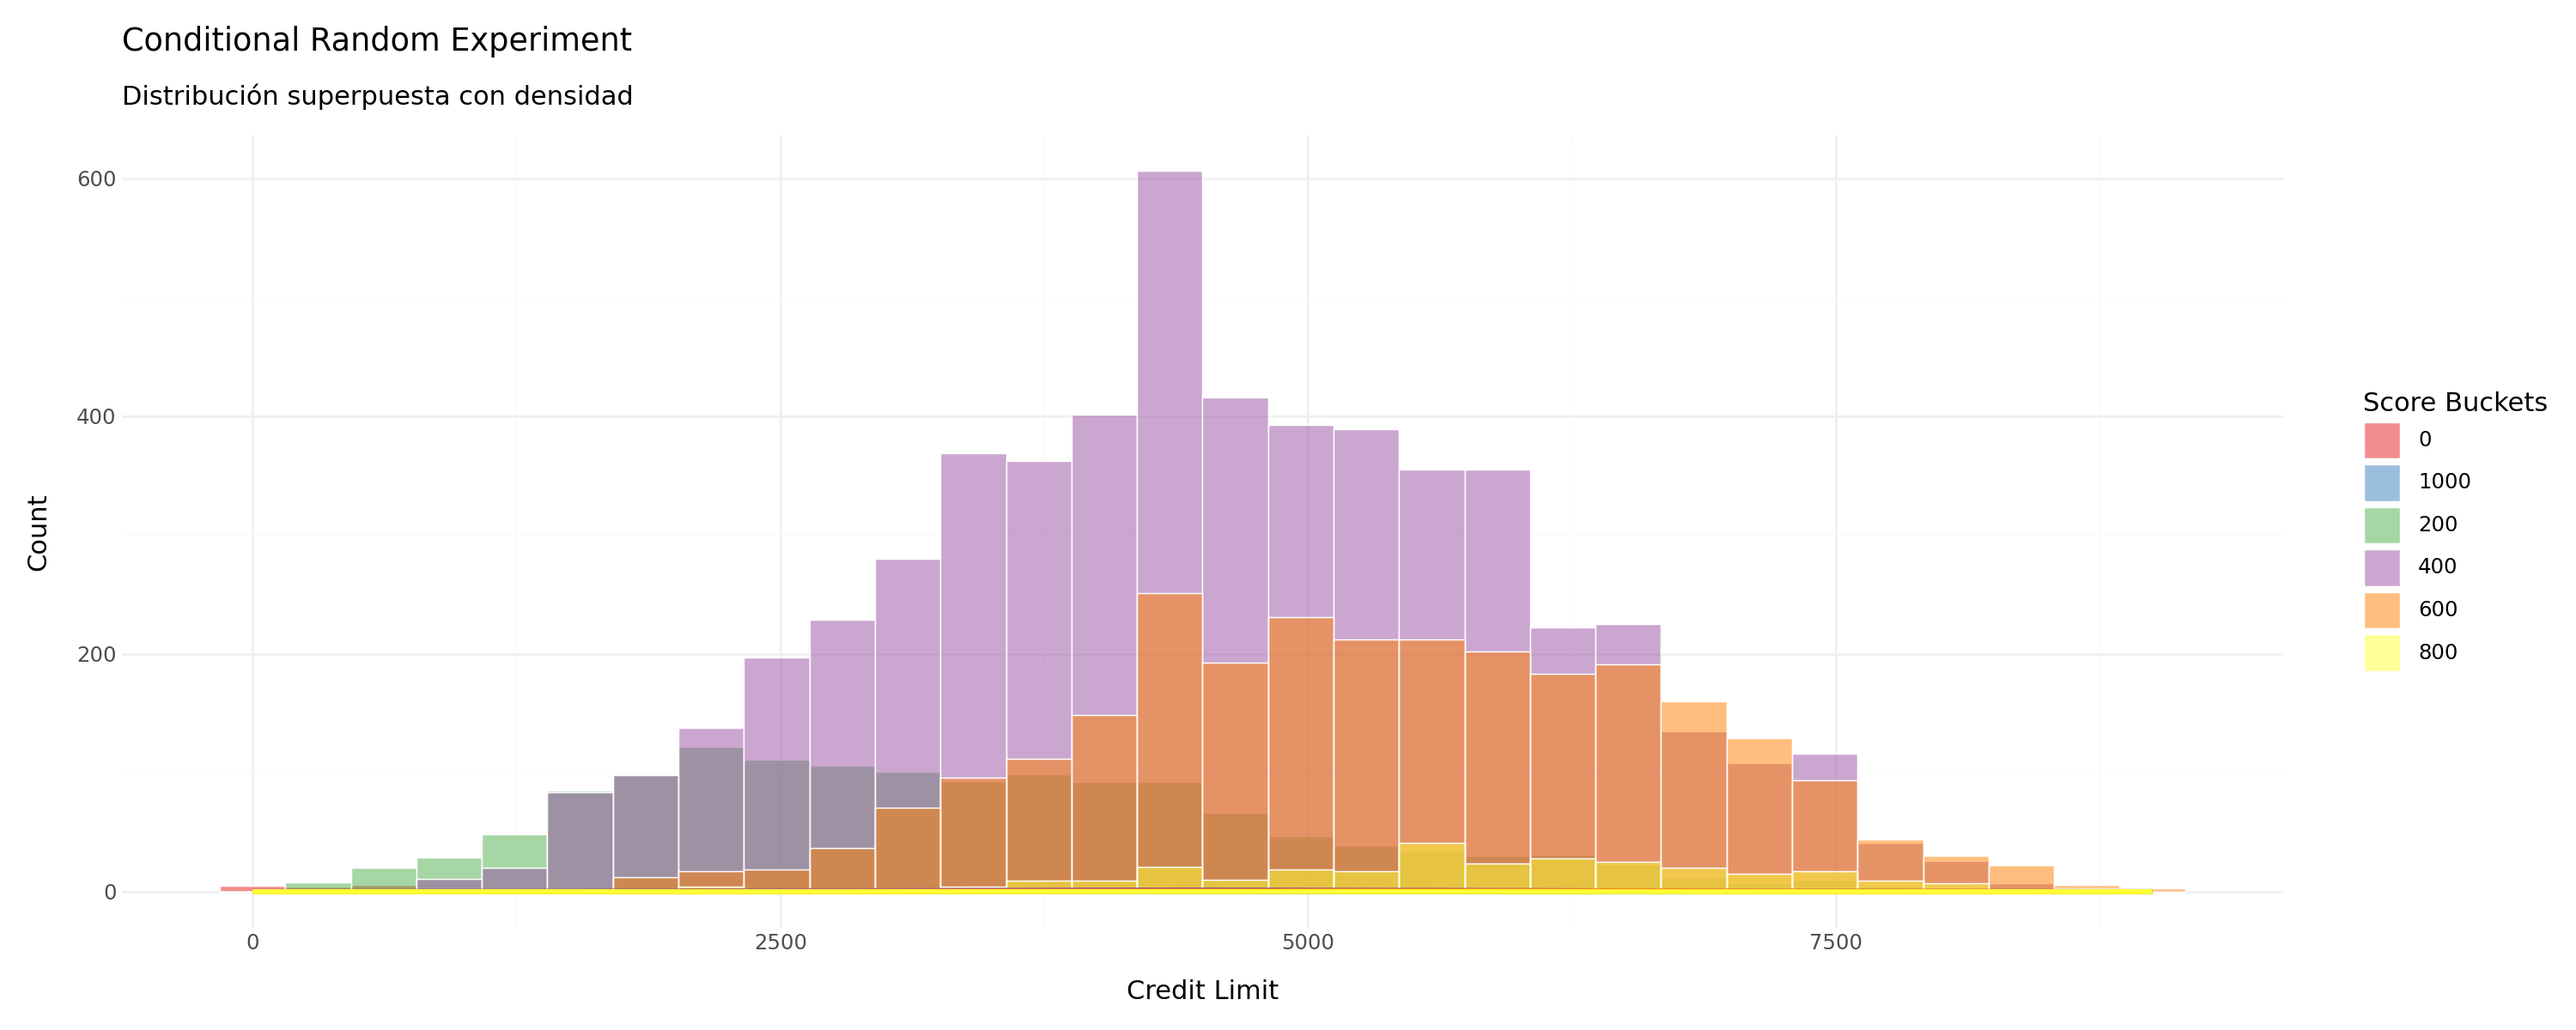

In [106]:
import polars as pl
from plotnine import *

# 1. Preparación en Polars
df_plot = risk_data_rnd.with_columns(
    pl.col("credit_score1_buckets").cast(pl.Utf8)
)

# 2. Gráfico Vibrante con Bordes Marcados
(
    # Convertimos a pandas dentro de ggplot()
    ggplot(df_plot, aes(x="credit_limit", fill="credit_score1_buckets", color="credit_score1_buckets"))
    + geom_histogram(
        aes(fill="credit_score1_buckets"), 
        alpha=0.5,           # Transparencia media para ver el cruce de colores
        position="identity", # Solapado (estilo Seaborn)
        bins=30,
        color="white",       # "Barras bien marcadas" con borde blanco
        size=0.3             # Grosor del borde
    )
    + geom_density(
        aes(y=after_stat('count')), # Escala la curva a la altura de las barras
        size=1.2,                   # Línea gruesa para que destaque la "banda"
        alpha=0,                    # Sin relleno bajo la curva (solo la línea)
        show_legend=False
    )
    # 3. COLORES VIBRANTES
    + scale_fill_brewer(type="qual", palette="Set1")  # Paleta intensa (Rojo, Azul, Verde, Morado...)
    + scale_color_brewer(type="qual", palette="Set1") # Las líneas coinciden con el relleno
    + labs(
        title="Conditional Random Experiment",
        subtitle="Distribución superpuesta con densidad",
        x="Credit Limit",
        y="Count",
        fill="Score Buckets",
        color="Score Buckets"
    )
    + theme_minimal()
    + theme(
        figure_size=(15, 6),
        legend_position='right',
        # Fondo blanco limpio para que los colores resalten más
        panel_grid_major=element_line(color="#f0f0f0") 
    )
)

## Dummy Variables

In [107]:
model = smf.ols(
    "default ~ credit_limit", data=risk_data_rnd.to_pandas()
).fit()
model.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,0.1369,0.009,15.081,0.000,0.119,0.155
credit_limit,-9.344e-06,1.85e-06,-5.048,0.000,-1.3e-05,-5.72e-06


In [108]:
risk_data_dummies = (
    risk_data_rnd.hstack(
        risk_data_rnd.select(
            pl.col("credit_score1_buckets")
            
        ).to_dummies()
         .rename(
            lambda c:  c.replace("credit_score1_buckets_", "sb_")
        )
    )
).drop("sb_0")
risk_data_dummies

wage,educ,exper,married,credit_score1,credit_score2,credit_score1_buckets,credit_limit,default,sb_1000,sb_200,sb_400,sb_600,sb_800
f64,i64,i64,i64,f64,f64,i64,f64,i64,u8,u8,u8,u8,u8
890.0,11,16,1,490.0,500.0,400,5400.0,0,0,0,1,0,0
670.0,11,7,1,196.0,481.0,200,3800.0,0,0,1,0,0,0
1220.0,14,9,1,392.0,611.0,400,5800.0,0,0,0,1,0,0
1210.0,15,8,1,627.0,519.0,600,6500.0,0,0,0,0,1,0
900.0,16,1,1,275.0,519.0,200,2100.0,0,0,1,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…
990.0,13,15,1,490.0,537.0,400,5200.0,0,0,0,1,0,0
950.0,10,19,1,392.0,481.0,400,3200.0,0,0,0,1,0,0
480.0,12,14,1,412.0,537.0,400,1900.0,0,0,0,1,0,0


La ecuación del modelo con variables dummy para los grupos ($G_i$) y el tratamiento ($\text{lines}_i$) se expresa así en notación LaTeX:

$$
\text{default}_i = \beta_0 + \beta_1\, \text{lines}_i + \theta\, G_i + e_i
$$

Donde:
- $\text{default}_i$: variable dependiente (incumplimiento del cliente $i$)
- $\text{lines}_i$: variable de tratamiento (por ejemplo, límite de crédito)
- $G_i$: vector de variables dummy para los grupos (por ejemplo, buckets de score)
- $\beta_1$: efecto marginal del tratamiento, ajustado por grupo
- $\theta$: vector de coeficientes para los grupos
- $e_i$: término de error



In [109]:
model = smf.ols(
    "default ~ credit_limit + sb_200 + sb_400 + sb_600 + sb_800 + sb_1000",
    data=risk_data_dummies.to_pandas()
).fit()
model.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,0.2253,0.056,4.000,0.000,0.115,0.336
credit_limit,4.652e-06,2.02e-06,2.305,0.021,6.97e-07,8.61e-06
sb_200,-0.0559,0.057,-0.981,0.327,-0.168,0.056
sb_400,-0.1442,0.057,-2.538,0.011,-0.256,-0.033
sb_600,-0.2148,0.057,-3.756,0.000,-0.327,-0.103
sb_800,-0.2489,0.060,-4.181,0.000,-0.366,-0.132
sb_1000,-0.2541,0.094,-2.715,0.007,-0.438,-0.071


In [110]:
model = smf.ols(
    "default ~ credit_limit + C(credit_score1_buckets)",
    data=risk_data_rnd.to_pandas()
).fit()
model.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,0.2253,0.056,4.000,0.000,0.115,0.336
C(credit_score1_buckets)[T.200],-0.0559,0.057,-0.981,0.327,-0.168,0.056
C(credit_score1_buckets)[T.400],-0.1442,0.057,-2.538,0.011,-0.256,-0.033
C(credit_score1_buckets)[T.600],-0.2148,0.057,-3.756,0.000,-0.327,-0.103
C(credit_score1_buckets)[T.800],-0.2489,0.060,-4.181,0.000,-0.366,-0.132
C(credit_score1_buckets)[T.1000],-0.2541,0.094,-2.715,0.007,-0.438,-0.071
credit_limit,4.652e-06,2.02e-06,2.305,0.021,6.97e-07,8.61e-06


In [111]:
plt_data = risk_data_rnd.with_columns(
    risk_prediction=pl.Series(model.fittedvalues)
).group_by(["credit_limit", "credit_score1_buckets"]).agg(
    pl.col("risk_prediction").mean()
).with_columns(
    pl.col("credit_score1_buckets").cast(pl.Utf8)
)
plt_data

credit_limit,credit_score1_buckets,risk_prediction
f64,str,f64
1500.0,"""200""",0.176414
7700.0,"""400""",0.116934
6200.0,"""200""",0.198278
6700.0,"""800""",0.007625
2800.0,"""400""",0.09414
…,…,…
5000.0,"""600""",0.033792
7300.0,"""200""",0.203395
4700.0,"""600""",0.032397


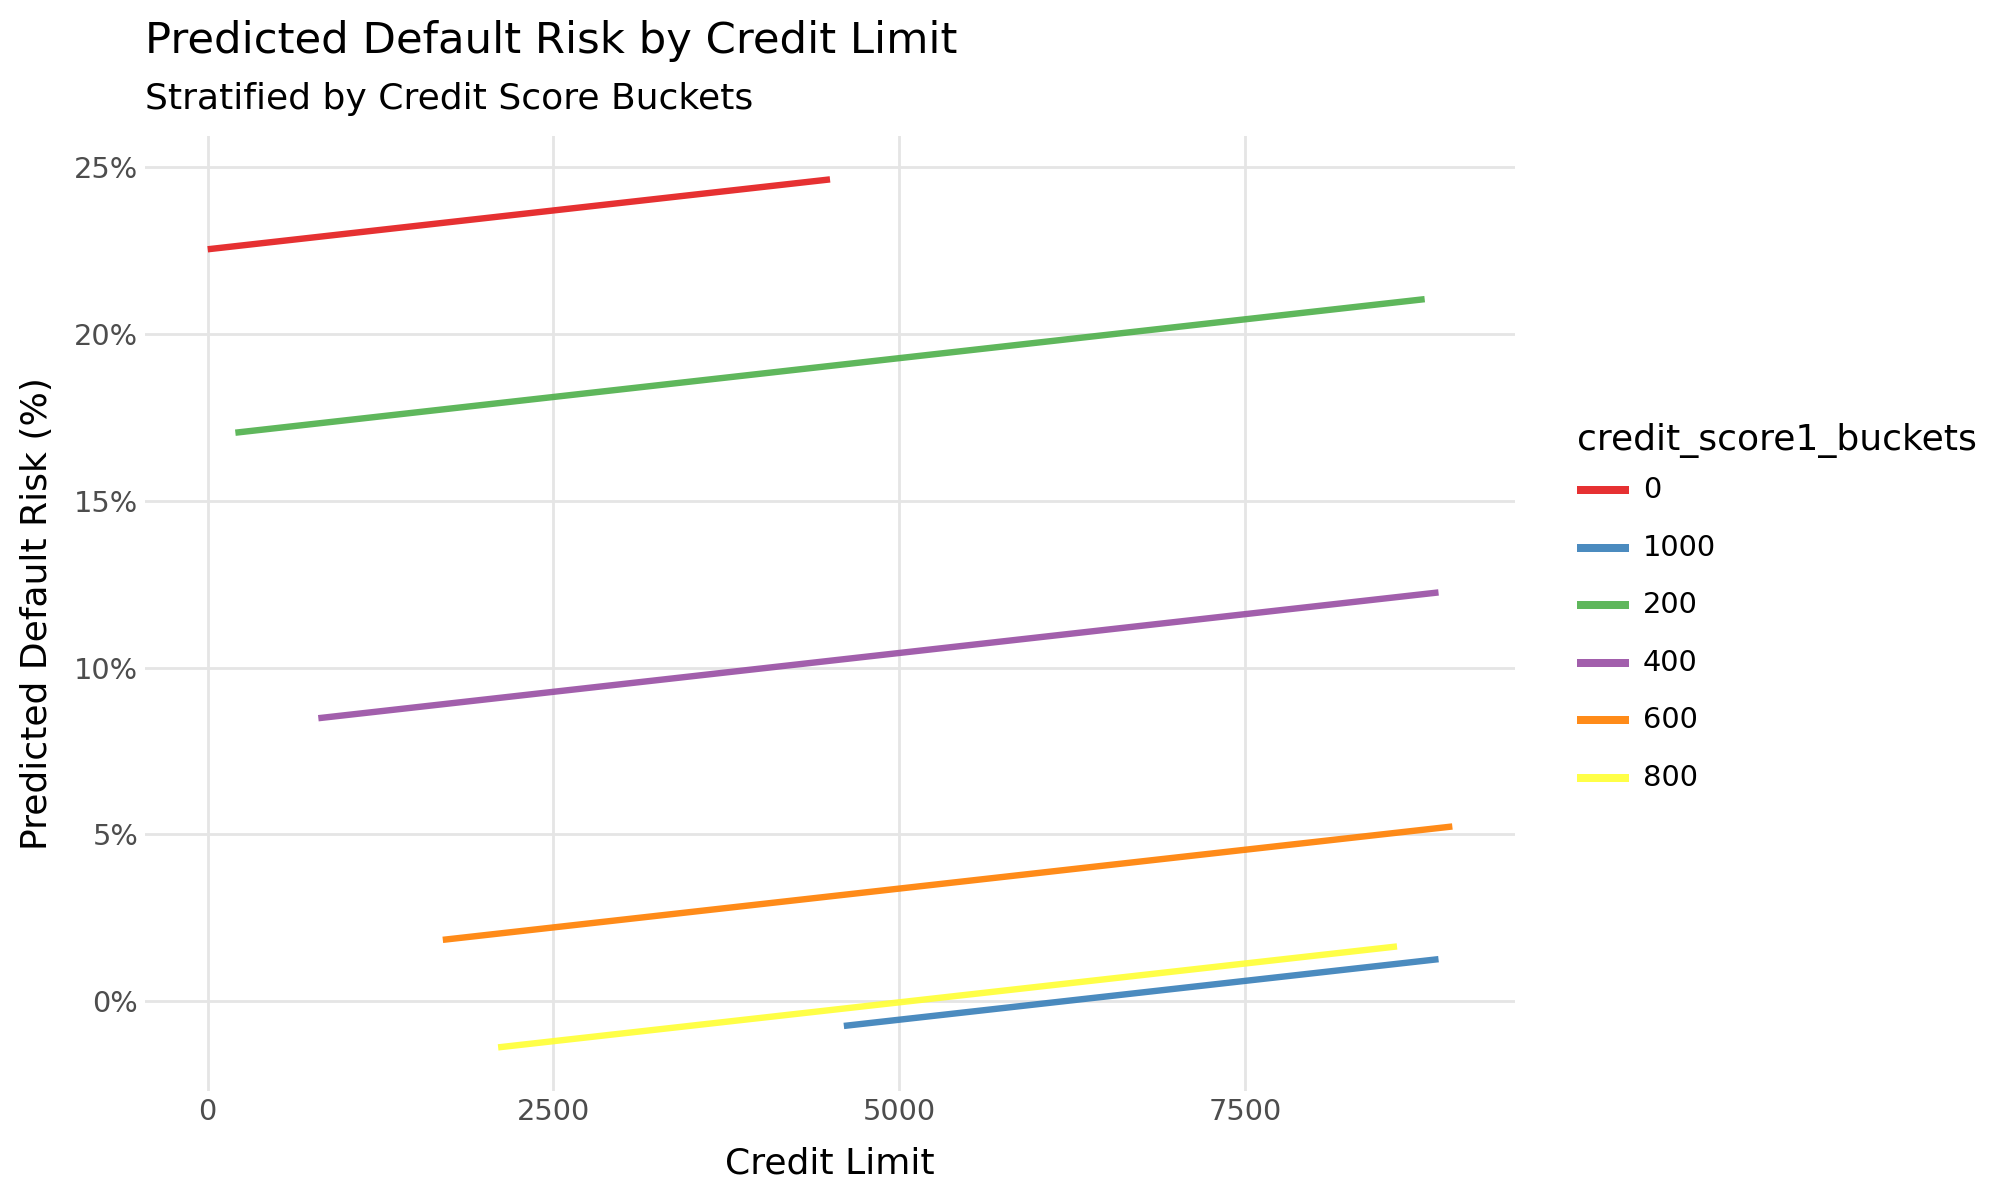

In [112]:
(
    ggplot(
        plt_data,
        aes(
            x="credit_limit",
            y="risk_prediction",
            color="credit_score1_buckets",
            group="credit_score1_buckets"
        )
    )
    + geom_line(size=1.3, alpha=0.9)
    + scale_color_brewer(type="qual", palette="Set1")
    + scale_y_continuous(labels=lambda l: [f"{v:.0%}" for v in l])
    + labs(
        title="Predicted Default Risk by Credit Limit",
        subtitle="Stratified by Credit Score Buckets",
        x="Credit Limit",
        y="Predicted Default Risk (%)",
    )
    + theme_minimal(base_size=13)
    + theme(
        figure_size=(10, 6),
        legend_position="right",
        panel_grid_minor=element_blank()
    )
)


## Saturated Regression Model

In [113]:
# 1. Tu función (intacta)
def regress(df, t, y):
    return smf.ols(f"{y}~{t}", data=df.to_pandas()).fit().params[t]

# 2. El código corregido
effect_by_group = (
    risk_data_rnd.group_by("credit_score1_buckets")
    .agg(
        pl.struct(["default", "credit_limit"])
        .map_batches(
            # CAMBIO AQUÍ: Envolvemos el resultado en pl.Series([ ... ])
            lambda x: pl.Series([regress(x.struct.unnest(), "credit_limit", "default")]),
            return_dtype=pl.Float64
        )
        .alias("effect")
    ).explode("effect")
)

print(effect_by_group)

shape: (6, 2)
┌───────────────────────┬───────────┐
│ credit_score1_buckets ┆ effect    │
│ ---                   ┆ ---       │
│ i64                   ┆ f64       │
╞═══════════════════════╪═══════════╡
│ 0                     ┆ -0.000071 │
│ 200                   ┆ 0.000007  │
│ 400                   ┆ 0.000005  │
│ 600                   ┆ 0.000003  │
│ 800                   ┆ 0.000002  │
│ 1000                  ┆ 0.0       │
└───────────────────────┴───────────┘


In [114]:
# 1. Obtenemos el tamaño de los grupos
group_size = risk_data_rnd.group_by("credit_score1_buckets").agg(pl.len().alias("size"))

# 2. El ATE en una sola línea
ate = (
    effect_by_group.join(group_size, on="credit_score1_buckets")
    .select(
        ate = pl.col("effect").dot(pl.col("size")) / pl.col("size").sum()
    )
    .item()
)

print(f"ATE estimado: {ate}")

ATE estimado: 4.490445628748727e-06


In [115]:
model = smf.ols("default ~ credit_limit * C(credit_score1_buckets)",
                data=risk_data_rnd.to_pandas()).fit()


model.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,0.3137,0.077,4.086,0.000,0.163,0.464
C(credit_score1_buckets)[T.200],-0.1521,0.079,-1.926,0.054,-0.307,0.003
C(credit_score1_buckets)[T.400],-0.2339,0.078,-3.005,0.003,-0.386,-0.081
C(credit_score1_buckets)[T.600],-0.2957,0.080,-3.690,0.000,-0.453,-0.139
C(credit_score1_buckets)[T.800],-0.3227,0.111,-2.919,0.004,-0.539,-0.106
C(credit_score1_buckets)[T.1000],-0.3137,0.428,-0.733,0.464,-1.153,0.525
credit_limit,-7.072e-05,4.45e-05,-1.588,0.112,-0.000,1.66e-05
credit_limit:C(credit_score1_buckets)[T.200],7.769e-05,4.48e-05,1.734,0.083,-1.01e-05,0.000
credit_limit:C(credit_score1_buckets)[T.400],7.565e-05,4.46e-05,1.696,0.090,-1.18e-05,0.000
credit_limit:C(credit_score1_buckets)[T.600],7.398e-05,4.47e-05,1.655,0.098,-1.37e-05,0.000


In [116]:
(model.params[model.params.index.str.contains("credit_limit:")]
 + model.params["credit_limit"]).round(9)

credit_limit:C(credit_score1_buckets)[T.200]     0.000007
credit_limit:C(credit_score1_buckets)[T.400]     0.000005
credit_limit:C(credit_score1_buckets)[T.600]     0.000003
credit_limit:C(credit_score1_buckets)[T.800]     0.000002
credit_limit:C(credit_score1_buckets)[T.1000]    0.000000
dtype: float64

In [117]:
plt_data = risk_data_rnd.with_columns(
    risk_prediction=pl.Series(model.fittedvalues)
).group_by(["credit_limit", "credit_score1_buckets"]).agg(
    pl.col("risk_prediction").mean()
).with_columns(
    pl.col("credit_score1_buckets").cast(pl.Utf8)
)
plt_data

credit_limit,credit_score1_buckets,risk_prediction
f64,str,f64
2000.0,"""600""",0.024507
3200.0,"""200""",0.183931
5500.0,"""800""",0.002826
6600.0,"""600""",0.03952
7400.0,"""400""",0.116335
…,…,…
1800.0,"""400""",0.088705
1800.0,"""200""",0.174169
6200.0,"""400""",0.110414


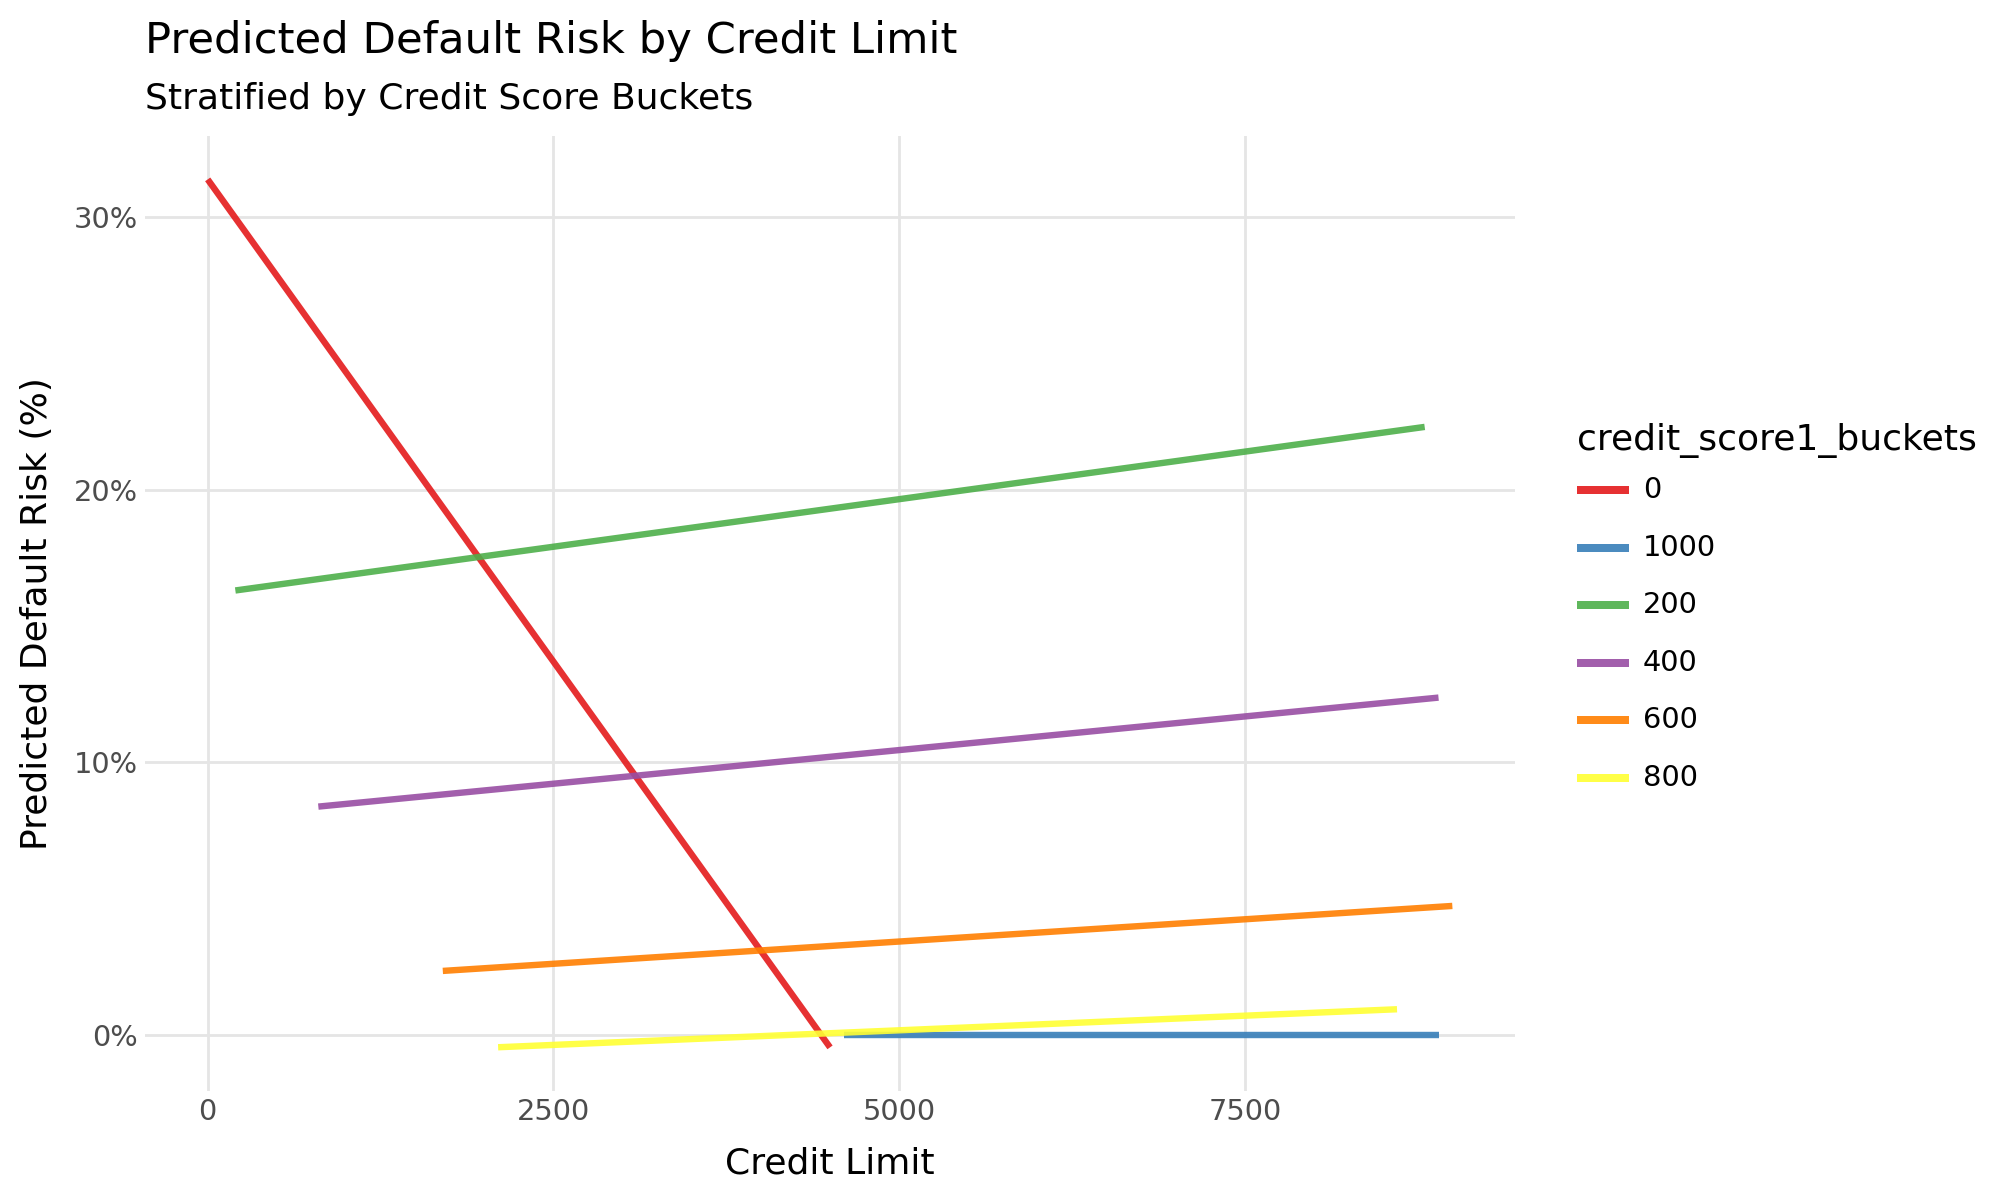

In [118]:
(
    ggplot(
        plt_data,
        aes(
            x="credit_limit",
            y="risk_prediction",
            color="credit_score1_buckets",
            group="credit_score1_buckets"
        )
    )
    + geom_line(size=1.3, alpha=0.9)
    + scale_color_brewer(type="qual", palette="Set1")
    + scale_y_continuous(labels=lambda l: [f"{v:.0%}" for v in l])
    + labs(
        title="Predicted Default Risk by Credit Limit",
        subtitle="Stratified by Credit Score Buckets",
        x="Credit Limit",
        y="Predicted Default Risk (%)",
    )
    + theme_minimal(base_size=13)
    + theme(
        figure_size=(10, 6),
        legend_position="right",
        panel_grid_minor=element_blank()
    )
)


## Regression as Variance Weighted Average

In [119]:
np.random.seed(123)

# std(t)=1

t1 = np.random.normal(0, 1, size=1000)
df1 =  pl.DataFrame(dict(
    t=t1,
    y=1*t1, #   ATE of 1
    g=1
    )
)

# std(t)=2

t2 = np.random.normal(0, 2, size=500)
df2 =  pl.DataFrame(dict(
    t=t2,
    y=2*t2, #   ATE of 1
    g=2
    )
)

df = pl.concat([df1, df2])
df

t,y,g
f64,f64,i32
-1.085631,-1.085631,1
0.997345,0.997345,1
0.282978,0.282978,1
-1.506295,-1.506295,1
-0.5786,-0.5786,1
…,…,…
0.431603,0.863207,2
-2.879471,-5.758943,2
-0.084015,-0.168029,2


In [120]:
effect_by_group = df.group_by(
    pl.col("g")
).agg([
    pl.struct(["t", "y"])
      .map_batches(lambda x: pl.Series([regress(x.struct.unnest(), "t", "y")]), return_dtype=pl.Float64)
      .alias("effect"),
    pl.len().alias("size")  # <--- Añade la columna size con el número de filas por grupo
]).explode("effect")

# 2. El ATE en una sola línea
ate = (
    effect_by_group
    .select(
        ate = pl.col("effect").dot(pl.col("size")) / pl.col("size").sum()
    )
    .item()
)

print(f"ATE estimado: {ate}")

ATE estimado: 1.3333333333333333


In [121]:
model = smf.ols("y ~ t +C(g)", data=df.to_pandas()).fit()
model.params

Intercept    0.024758
C(g)[T.2]    0.019860
t            1.625775
dtype: float64

- **La regresión no promedia por tamaño de grupo:** Cuando ajustas un modelo como $y \sim t + C(g)$ (sin interacción), el coeficiente de $t$ **no** es simplemente el promedio ponderado por tamaño de muestra de los efectos por grupo. Si calculas el ATE así, obtienes $ATE = \frac{1 \times 1000 + 2 \times 500}{1500} = 1.33$.

- **La regresión pondera por varianza del tratamiento:** El coeficiente de $t$ en la regresión múltiple es un promedio ponderado de los efectos por grupo, pero los pesos son proporcionales a la **varianza del tratamiento** en cada grupo ($w_g \propto \sigma^2_{T|g}$), no al tamaño del grupo.

- **Grupos con más variabilidad en el tratamiento pesan más:** Si en un grupo el tratamiento varía mucho, la regresión le da más peso porque hay más información sobre el efecto causal. Si el tratamiento apenas cambia en un grupo, su efecto es menos confiable y recibe menos peso.

- **Implicación causal:** La estimación de la regresión responde a la pregunta: “¿Cuál es el efecto promedio del tratamiento, ponderando más los grupos donde el tratamiento realmente varía?” Esto es clave en contextos donde la asignación del tratamiento no es homogénea entre grupos.

- **Importancia práctica:** Entender esta diferencia es fundamental en inferencia causal y econometría aplicada (por ejemplo, en diferencias-en-diferencias). Si quieres el ATE poblacional, debes decidir si ponderar por tamaño de grupo o por varianza del tratamiento, según el contexto y la pregunta causal.


## De-Meaning and Fixed Effects

In [122]:
model_deb = smf.ols("credit_limit ~ C(credit_score1_buckets)",
                    data=risk_data_rnd.to_pandas()).fit()
model_deb.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,1173.0769,278.994,4.205,0.000,626.193,1719.961
C(credit_score1_buckets)[T.200],2195.4337,281.554,7.798,0.000,1643.530,2747.337
C(credit_score1_buckets)[T.400],3402.3796,279.642,12.167,0.000,2854.224,3950.535
C(credit_score1_buckets)[T.600],4191.3235,280.345,14.951,0.000,3641.790,4740.857
C(credit_score1_buckets)[T.800],4639.5105,291.400,15.921,0.000,4068.309,5210.712
C(credit_score1_buckets)[T.1000],5006.9231,461.255,10.855,0.000,4102.771,5911.076


In [123]:
risk_data_rnd.group_by(
    "credit_score1_buckets"
).agg(pl.col("credit_limit").mean()).sort(by="credit_score1_buckets")

credit_score1_buckets,credit_limit
i64,f64
0,1173.076923
200,3368.510638
400,4575.456498
600,5364.400448
800,5812.587413
1000,6180.0


In [126]:
risk_data_rnd_fe = risk_data_rnd.with_columns(
    pl.col("credit_limit").mean().over("credit_score1_buckets").alias("credit_limit_avg")
)
risk_data_rnd_fe

wage,educ,exper,married,credit_score1,credit_score2,credit_score1_buckets,credit_limit,default,credit_limit_avg
f64,i64,i64,i64,f64,f64,i64,f64,i64,f64
890.0,11,16,1,490.0,500.0,400,5400.0,0,4575.456498
670.0,11,7,1,196.0,481.0,200,3800.0,0,3368.510638
1220.0,14,9,1,392.0,611.0,400,5800.0,0,4575.456498
1210.0,15,8,1,627.0,519.0,600,6500.0,0,5364.400448
900.0,16,1,1,275.0,519.0,200,2100.0,0,3368.510638
…,…,…,…,…,…,…,…,…,…
990.0,13,15,1,490.0,537.0,400,5200.0,0,4575.456498
950.0,10,19,1,392.0,481.0,400,3200.0,0,4575.456498
480.0,12,14,1,412.0,537.0,400,1900.0,0,4575.456498


In [127]:
model = smf.ols("default ~ I(credit_limit-credit_limit_avg)",
    data=risk_data_rnd_fe.to_pandas()).fit()
model.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,0.0935,0.003,32.121,0.000,0.088,0.099
I(credit_limit - credit_limit_avg),4.652e-06,2.05e-06,2.273,0.023,6.4e-07,8.66e-06


In [128]:
model = smf.ols("default ~ credit_limit + credit_limit_avg",
    data=risk_data_rnd_fe.to_pandas()).fit()
model.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,0.4325,0.020,21.418,0.000,0.393,0.472
credit_limit,4.652e-06,2.02e-06,2.305,0.021,6.96e-07,8.61e-06
credit_limit_avg,-7.763e-05,4.75e-06,-16.334,0.000,-8.69e-05,-6.83e-05


## Omitted Variable Bias: Confounding Through 
## the Lens of Regression

In [130]:
short_model = smf.ols("default ~ credit_limit", data=risk_data.to_pandas()).fit()
float(short_model.params["credit_limit"])

-2.4019619925968688e-05

In [131]:
long_model = smf.ols("default ~ credit_limit + wage",
    data=risk_data.to_pandas()).fit()
omitted_model = smf.ols("wage ~ credit_limit", data=risk_data.to_pandas()).fit()
(long_model.params["credit_limit"] 
+ long_model.params["wage"]*omitted_model.params["credit_limit"])

np.float64(-2.401961992596871e-05)

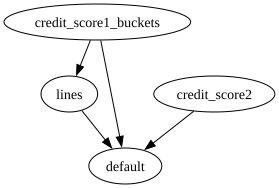

In [133]:
from graphviz import Digraph

dot = Digraph()
dot.edge("credit_score1_buckets", "lines")
dot.edge("credit_score1_buckets", "default")
dot.edge("lines", "default")
dot.edge("credit_score2", "default")
dot

In [134]:
formula = "default~credit_limit+C(credit_score1_buckets)+credit_score2"
model = smf.ols(formula, data=risk_data_rnd.to_pandas()).fit()
model.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,0.5576,0.055,10.132,0.000,0.450,0.665
C(credit_score1_buckets)[T.200],-0.0387,0.055,-0.710,0.478,-0.146,0.068
C(credit_score1_buckets)[T.400],-0.1032,0.054,-1.898,0.058,-0.210,0.003
C(credit_score1_buckets)[T.600],-0.1410,0.055,-2.574,0.010,-0.248,-0.034
C(credit_score1_buckets)[T.800],-0.1161,0.057,-2.031,0.042,-0.228,-0.004
C(credit_score1_buckets)[T.1000],-0.0430,0.090,-0.479,0.632,-0.219,0.133
credit_limit,4.928e-06,1.93e-06,2.551,0.011,1.14e-06,8.71e-06
credit_score2,-0.0007,2.34e-05,-30.225,0.000,-0.001,-0.001


In [135]:
model.bse["credit_limit"]

np.float64(1.9315591998936754e-06)

### Noise Inducing Control

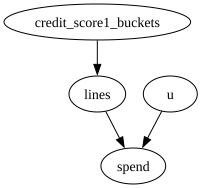

In [137]:
from graphviz import Digraph

dot = Digraph()
dot.edge("credit_score1_buckets", "lines")
dot.edge("lines", "spend")
dot.edge("u", "spend")
dot

In [136]:
spend_data_rnd = pl.read_csv("../data/spend_data_rnd.csv")
model = smf.ols("spend ~ np.sqrt(credit_limit)",
    data=spend_data_rnd.to_pandas()).fit()
model.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,2153.2154,218.600,9.850,0.000,1723.723,2582.708
np.sqrt(credit_limit),16.2915,2.988,5.452,0.000,10.420,22.163


In [138]:
model = smf.ols("spend~np.sqrt(credit_limit)+C(credit_score1_buckets)",
    data=spend_data_rnd.to_pandas()).fit()
model.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,2367.4867,556.273,4.256,0.000,1274.528,3460.446
C(credit_score1_buckets)[T.200],-144.7921,591.613,-0.245,0.807,-1307.185,1017.601
C(credit_score1_buckets)[T.400],-118.3923,565.364,-0.209,0.834,-1229.211,992.427
C(credit_score1_buckets)[T.600],-111.5738,570.471,-0.196,0.845,-1232.429,1009.281
C(credit_score1_buckets)[T.800],-89.7366,574.645,-0.156,0.876,-1218.791,1039.318
C(credit_score1_buckets)[T.1000],363.8990,608.014,0.599,0.550,-830.720,1558.518
np.sqrt(credit_limit),14.5953,3.523,4.142,0.000,7.673,21.518


Solo ajusta por cofundidores que expliquen el tratamiento y el outcome. Ajustar por variables irrelevantes puede aumentar el error estándar y reducir la precisión del estimador causal.

### Feature Selection: A Bias-Variance Trade-Of

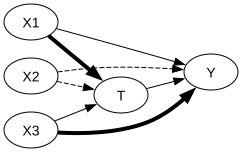

In [139]:
import graphviz

# Crear el objeto Digraph
dot = graphviz.Digraph('Causal_Selection', comment='Selección de Controles')

# Configuración general del gráfico
dot.attr(rankdir='LR', size='8,5')
dot.attr('node', shape='ellipse', fontname='Arial')

# Definición de nodos
dot.node('X1', 'X1')
dot.node('X2', 'X2')
dot.node('X3', 'X3')
dot.node('T', 'T')
dot.node('Y', 'Y')

# Alineación por columnas (Ranks)
with dot.subgraph() as s:
    s.attr(rank='same')
    s.node('X1')
    s.node('X2')
    s.node('X3')

# Edges (Conexiones)
# X1: Confusor (Fuerte en T, normal en Y)
dot.edge('X1', 'T', penwidth='4')
dot.edge('X1', 'Y', penwidth='1')

# X2: Inductor de Ruido (Punteado en ambos)
dot.edge('X2', 'T', style='dashed')
dot.edge('X2', 'Y', style='dashed')

# X3: Control Neutral (Normal en T, fuerte en Y)
dot.edge('X3', 'T', penwidth='1')
dot.edge('X3', 'Y', penwidth='4')

# Efecto del Tratamiento
dot.edge('T', 'Y', penwidth='1')

# Forzar orden vertical invisible para que X1, X2 y X3 queden uno sobre otro
dot.edge('X1', 'X2', style='invis')
dot.edge('X2', 'X3', style='invis')

# Renderizar y mostrar
dot.render('dag_seleccion_controles', format='png', cleanup=True)
dot

In [140]:
np.random.seed(123)
n = 100
(x1, x2, x3) = (np.random.normal(0, 1, n) for _ in range(3))
t = np.random.normal(10*x1 + 5*x2 + x3)
# ate = 0.05
y = np.random.normal(0.05*t + x1 + 5*x2 + 10*x3, 5)
df = pl.DataFrame(dict(y=y, t=t, x1=x1, x2=x2, x3=x3))
smf.ols("y~t+x1+x2+x3", data=df.to_pandas()).fit().summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,0.2707,0.527,0.514,0.608,-0.775,1.316
t,0.8664,0.607,1.427,0.157,-0.339,2.072
x1,-7.0628,6.038,-1.170,0.245,-19.049,4.923
x2,0.0143,3.128,0.005,0.996,-6.195,6.224
x3,9.6292,0.887,10.861,0.000,7.869,11.389


In [141]:
smf.ols("y~t+x2+x3", data=df.to_pandas()).fit().summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,0.1889,0.523,0.361,0.719,-0.849,1.227
t,0.1585,0.046,3.410,0.001,0.066,0.251
x2,3.6095,0.582,6.197,0.000,2.453,4.766
x3,10.4549,0.537,19.453,0.000,9.388,11.522


### Resumen de Ideas Clave: La Regresión como Herramienta de Ajuste

En este capítulo, hemos redefinido la regresión lineal. No la utilizamos como una herramienta de predicción (donde el $R^2$ sería el protagonista), sino como un mecanismo de **ajuste causal** para eliminar el sesgo de confusión.

#### 1. Ortogonalización y el Teorema FWL
La idea central es que podemos "limpiar" nuestra estimación mediante la ortogonalización. El **Teorema de Frisch-Waugh-Lovell (FWL)** descompone una regresión múltiple en tres pasos conceptuales:

1.  **Debiasing (Des-biasear el Tratamiento):** Regresamos el tratamiento $T$ sobre los confundidores $X$ para obtener los residuos $\tilde{T} = T - \hat{T}$. Esto representa la variación del tratamiento que es independiente de $X$.
2.  **Denoising (Reducción de Ruido en el Outcome):** Regresamos el resultado $Y$ sobre $X$ para obtener los residuos $\tilde{Y} = Y - \hat{Y}$. Esto elimina la varianza en $Y$ explicada por los confundidores.
3.  **Estimación Causal:** Regresamos $\tilde{Y}$ sobre $\tilde{T}$. El coeficiente resultante es el efecto causal puro, idéntico al de una regresión múltiple completa.

#### 2. Regresión como Promedio Ponderado
Cuando usamos variables categóricas (dummies), la regresión no calcula un promedio simple del efecto en cada grupo. En su lugar, realiza un **promedio ponderado por la varianza del tratamiento** en cada estrato:
$$
\beta_{OLS} = \frac{\sum_g w_g \beta_g}{\sum_g w_g} \text{ donde } w_g = P(G=g) \cdot Var(T|G=g)
$$
Esto significa que los grupos donde el tratamiento varía más tienen mayor peso en la estimación final.

#### 3. Selección de Controles: El sesgo de variable omitida
No todos los controles son beneficiosos. Hemos aprendido a distinguir entre:
*   **Buenos controles:** Variables que afectan tanto a $T$ como a $Y$ (confundidores).
*   **Reductores de varianza:** Variables que solo afectan a $Y$ (ayudan a la precisión).
*   **Inductores de ruido:** Variables que solo afectan a $T$ (pueden aumentar el error estándar).



### Criterios Prácticos para la Selección de Controles

Para decidir si una variable $X$ debe entrar en tu modelo causal, puedes apoyarte en estas dos reglas de oro que equilibran el sesgo y la varianza:

#### 1. El Ratio de Fuerza (Fuerza Relativa)
Este ratio compara qué tan "fuerte" es la variable para explicar el tratamiento ($T$) frente a qué tan "fuerte" es para explicar el resultado ($Y$):

$$
Ratio = \frac{R^2(X \to T)}{R^2(X \to Y)}
$$

*   **Si el Ratio > 5 (Inductor de Ruido):** La variable es mucho más potente explicando por qué alguien recibe el tratamiento que explicando el resultado final. Al incluirla, "limpias" tanto el tratamiento que te quedas sin varianza útil para estimar el efecto, disparando el error estándar. **Piénsalo dos veces antes de incluirla.**
*   **Si el Ratio < 0.2 (Control Neutral):** La variable es excelente explicando el resultado pero casi no afecta la asignación del tratamiento. **¡Inclúyela siempre!** Ayuda a reducir el ruido en $Y$ (denoising) y hace que tu estimador sea mucho más preciso.

#### 2. VIF (Factor de Inflación de la Varianza)
El VIF mide la multicolinealidad, es decir, qué tanto se "enciman" tus variables predictoras.

*   **VIF > 5 o 10:** Si al añadir una variable el VIF de tu tratamiento $T$ cruza este umbral, la variable está **"asfixiando"** a tu tratamiento. Le está robando su varianza única, lo que hace que el modelo no pueda distinguir qué parte del efecto le pertenece a $T$ y qué parte a $X$.